# AUDIAX — Notebook Referensi End-to-End (versi **optimized**)

Turunan dari `audiax_pipeline_FRD.ipynb`. Semua struktur, protokol evaluasi, dan
keputusan desain lama dipertahankan; yang ditambahkan adalah paket optimasi **T6**
(lihat Bagian 31) yang bertujuan mengalahkan BEATs beku di unit baru tanpa merusak
fitur pretrained. Artefak keluaran memakai akhiran `_opt` supaya tidak menimpa hasil
run lama — kedua versi bisa diadu langsung dari disk.


## 1. Verifikasi Dependensi


In [1]:
import importlib.util

_REQUIRED = [
    "torch", "torchaudio", "soundfile", "onedrivedownloader",
    "pandas", "sklearn", "matplotlib", "tabulate", "scipy", "numpy",
]
_missing = [m for m in _REQUIRED if importlib.util.find_spec(m) is None]
if _missing:
    raise RuntimeError(
        "Dependensi belum terpasang: " + ", ".join(_missing) + ". "
        "Jalankan `pip install -r requirements.txt` (root repo) sebelum "
        "menjalankan notebook ini."
    )
print("Semua dependensi terpasang (lihat requirements.txt di root repo).")


Semua dependensi terpasang (lihat requirements.txt di root repo).


### 1b. Verifikasi GPU


In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("GPU tersedia:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("PERINGATAN: tidak ada GPU terdeteksi -- fine-tuning transformer di "
          "CPU sangat lambat. Kalau memakai Colab: Runtime > Change runtime type > GPU.")


PyTorch: 2.6.0+cu126
CUDA build: 12.6
GPU tersedia: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 2. Source BEATs (vendored lokal)


In [3]:
import sys
from pathlib import Path

BEATS_DIR = Path("../third_party/unilm/beats")
if not BEATS_DIR.exists():
    raise RuntimeError(
        f"{BEATS_DIR} tidak ditemukan. Notebook ini tidak lagi meng-clone BEATs "
        "secara otomatis -- vendor manual dulu (lihat README.md) sebelum lanjut."
    )

sys.path.insert(0, str(BEATS_DIR.resolve()))
print("BEATs source siap dari:", BEATS_DIR.resolve())


BEATs source siap dari: D:\AIC\audiax_model\third_party\unilm\beats


## 3. Checkpoint BEATs Pretrained (lokal, `models/`)


In [4]:
import os

BASE_CHECKPOINT = "../models/BEATs_iter3_plus_AS20K.pt"
MIN_VALID_SIZE_BYTES = 300_000_000


def _looks_valid(path: str) -> bool:
    return os.path.exists(path) and os.path.getsize(path) > MIN_VALID_SIZE_BYTES


if not _looks_valid(BASE_CHECKPOINT):
    raise RuntimeError(
        f"Checkpoint tidak ditemukan atau tidak valid: {BASE_CHECKPOINT}. "
        "Notebook ini tidak lagi mengunduh checkpoint secara otomatis -- taruh "
        "file .pt di folder models/ sebelum menjalankan sel ini."
    )

print(f"Checkpoint pretrained siap: {BASE_CHECKPOINT} "
      f"({os.path.getsize(BASE_CHECKPOINT)/1e6:.0f} MB)")


Checkpoint pretrained siap: ../models/BEATs_iter3_plus_AS20K.pt (361 MB)


## 4. Dataset — Pilih Mode


In [5]:
DATASET_MODE = "local"

assert DATASET_MODE in ("mimii", "local"), f"DATASET_MODE tidak dikenal: {DATASET_MODE}"
print(f"DATASET_MODE = {DATASET_MODE}")

USES_HELDOUT_UNIT = DATASET_MODE in ("mimii", "local")


DATASET_MODE = local


### 4a. Mode `"mimii"` — Unduh Dataset Publik (`-6_dB_fan`, ~10.9 GB)


In [6]:
import hashlib

if DATASET_MODE == "mimii":
    MIMII_ROOT = "mimii_data"
    MIMII_ZIP_URL = "https://zenodo.org/records/3384388/files/-6_dB_fan.zip?download=1"
    MIMII_ZIP_NAME = "-6_dB_fan.zip"
    MIMII_ZIP_MD5 = "f02ae808a58d84b6815b7ec38ff30879"
    MIMII_ZIP_MIN_SIZE = 10_000_000_000

    def _md5sum(path: str, chunk_size: int = 8 * 1024 * 1024) -> str:
        h = hashlib.md5()
        with open(path, "rb") as f:
            for chunk in iter(lambda: f.read(chunk_size), b""):
                h.update(chunk)
        return h.hexdigest()

    os.makedirs(MIMII_ROOT, exist_ok=True)
    extracted_marker = os.path.join(MIMII_ROOT, "-6_dB_fan")

    if os.path.isdir(extracted_marker) and len(os.listdir(extracted_marker)) > 0:
        print(f"Dataset sudah terekstrak di {extracted_marker} -- lewati unduhan.")
    else:
        if not os.path.exists(MIMII_ZIP_NAME) or os.path.getsize(MIMII_ZIP_NAME) < MIMII_ZIP_MIN_SIZE:
            print("Mengunduh -6_dB_fan.zip (~10.9 GB) -- bisa lama...")
            os.system(f"wget -c -q --show-progress '{MIMII_ZIP_URL}' -O {MIMII_ZIP_NAME}")
        assert os.path.exists(MIMII_ZIP_NAME) and os.path.getsize(MIMII_ZIP_NAME) >= MIMII_ZIP_MIN_SIZE, (
            f"Unduhan tidak lengkap: {os.path.getsize(MIMII_ZIP_NAME)/1e9:.2f} GB, seharusnya ~10.9 GB."
        )
        print("Memverifikasi checksum MD5...")
        actual_md5 = _md5sum(MIMII_ZIP_NAME)
        assert actual_md5 == MIMII_ZIP_MD5, f"Checksum tidak cocok! {actual_md5} != {MIMII_ZIP_MD5}"
        print("Checksum cocok. Mengekstrak...")
        os.makedirs(extracted_marker, exist_ok=True)
        os.system(f"unzip -q -o {MIMII_ZIP_NAME} -d {extracted_marker}")

    assert os.path.isdir(extracted_marker), f"{extracted_marker} tidak ditemukan setelah ekstraksi."
    DATASET_ROOT = MIMII_ROOT
    print("Dataset MIMII siap di:", extracted_marker)
else:
    print("DATASET_MODE != 'mimii' -- sel unduhan dilewati.")

DATASET_MODE != 'mimii' -- sel unduhan dilewati.


### 4b. Mode `"local"` — Dataset Multi-Unit Lokal (`Dataset/id_XX/...`)


In [7]:
if DATASET_MODE == "local":
    from pathlib import Path
    LOCAL_MULTI_ROOT = "../Dataset"

    assert os.path.isdir(LOCAL_MULTI_ROOT), f"Folder dataset tidak ditemukan: {LOCAL_MULTI_ROOT}"
    found_ids = sorted(
        p.name for p in Path(LOCAL_MULTI_ROOT).iterdir() if p.is_dir() and p.name.startswith("id_")
    )
    assert found_ids, f"Tidak ada folder id_XX di {LOCAL_MULTI_ROOT}."

    counts = {}
    for mid in found_ids:
        for lab in ("normal", "abnormal"):
            d = Path(LOCAL_MULTI_ROOT, mid, lab)
            assert d.is_dir(), f"Folder {d} tidak ditemukan."
            n = len(list(d.glob("*.wav")))
            assert n > 0, f"Folder {d} tidak berisi file .wav."
            counts[(mid, lab)] = n

    DATASET_ROOT = LOCAL_MULTI_ROOT
    print(f"Dataset local_multi siap di: {LOCAL_MULTI_ROOT}. Machine IDs: {found_ids}")
    for (mid, lab), n in sorted(counts.items()):
        print(f"  {mid}/{lab}: {n} klip")
    print("Held-out akan berbasis UNIT PENUH (holdout_machine_id di Bagian 5 Config), "
          "sama seperti mode 'mimii' -- lihat Bagian 9.")
else:
    print("DATASET_MODE != 'local_multi' -- sel ini dilewati.")


Dataset local_multi siap di: ../Dataset. Machine IDs: ['id_00', 'id_02', 'id_04', 'id_06']
  id_00/abnormal: 407 klip
  id_00/normal: 1011 klip
  id_02/abnormal: 359 klip
  id_02/normal: 1016 klip
  id_04/abnormal: 348 klip
  id_04/normal: 1033 klip
  id_06/abnormal: 361 klip
  id_06/normal: 1015 klip
Held-out akan berbasis UNIT PENUH (holdout_machine_id di Bagian 5 Config), sama seperti mode 'mimii' -- lihat Bagian 9.


## 5. Konfigurasi


In [8]:
import warnings, copy
from collections import defaultdict
from contextlib import contextmanager
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Optional, List, Dict, Tuple, Callable
import numpy as np
import pandas as pd
import scipy.signal as sig
import scipy.ndimage as ndi
import torch
import torch.nn as nn
import torch.nn.functional as F
import soundfile as sf
import torchaudio
from torch import Tensor
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score, silhouette_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")


@dataclass
class Config:
    sr: int = 16000
    min_duration_sec: float = 2.0
    max_clipping_ratio: float = 0.001
    min_snr_db: float = -10.0
    silence_rms: float = 1e-4
    bp_low: float = 50.0
    bp_high: float = 7500.0
    bp_order: int = 4
    notch_low: float = 300.0
    notch_high: float = 3400.0
    notch_order: int = 2
    window_sec: float = 2.0
    hop_sec: float = 1.0

    # --- Jalur data (T3): semua default DIPERTAHANKAN persis seperti perilaku lama.
    # Tidak satu pun default di bawah boleh diubah tanpa angka dari ablasi Bagian 29b,
    # mengikuti preseden Keputusan Desain #4 di CLAUDE.md untuk enable_denoise.
    audio_channel: Optional[int] = None   # None = rata-rata semua kanal (perilaku lama);
                                          # int = pakai satu kanal saja (MIMII = array 8 mik)
    normalize_mode: str = "peak"          # "peak" (lama) | "rms" (pertahankan level relatif)
    rms_target: float = 0.1
    enable_privacy_notch: bool = True     # bandstop 300-3400 Hz; matikan hanya untuk ablasi

    enable_denoise: bool = False
    denoise_harm_kernel: int = 31
    denoise_perc_kernel: int = 31
    denoise_mask_power: float = 2.0
    denoise_mask_floor: float = 0.1

    dataset_root: str = DATASET_ROOT
    snr_level: str = "-6_dB"
    machine_type: str = "fan"
    holdout_machine_id: str = "id_04"
    holdout_frac: float = 0.20
    per_unit_test_frac: float = 0.20      # klip tes yang dicadangkan dari SETIAP unit seen
    max_clips_per_class_per_id: Optional[int] = None
    train_val_split_frac: float = 0.2

    n_unfrozen_layers: int = 2
    head_dropout: float = 0.3
    finetune_lr_backbone: float = 2e-5
    finetune_lr_head: float = 1e-3
    finetune_weight_decay: float = 1e-2
    finetune_batch_size: int = 16
    finetune_epochs_max: int = 30
    finetune_patience: int = 5
    finetune_warmup_ratio: float = 0.1

    focal_alpha: float = 0.5
    focal_gamma: float = 2.0

    aug_pitch_range: float = 2.0
    aug_gain_range_db: float = 6.0
    aug_noise_snr: Tuple[float, float] = (10.0, 30.0)

    knn_k: int = 5
    pca_variance_target: float = 0.95
    mahalanobis_shrinkage: float = 0.1
    z_warning: float = 3.0
    z_critical: float = 6.0
    min_calibration_windows: int = 20

    # --- Metrik operasional (T1)
    pauc_max_fpr: float = 0.10            # pAUC standar DCASE (p=0.1)
    topk_frac: float = 0.20               # agregasi "topk" = rata-rata 20% window ter-anomali

    # --- Objective adapter: Machine Attribute Classification (T4)
    # Label yang dilatihkan adalah machine_id, BUKAN normal/abnormal. Ini premis
    # training-free ASD (Keputusan Desain #1): label anomali hanya untuk evaluasi.
    mac_head: str = "arcface"             # "arcface" | "linear" (kontrol untuk ablasi)
    # scale/margin ArcFace standar (30 / 0.2) dirancang untuk ratusan-ribuan kelas
    # (kasus umum: pengenalan wajah). Dengan cuma N_MAC_CLASSES yang sedikit, margin
    # sebesar itu memaksa tiap kelas mengumpul terlalu rapat -- bagus untuk akurasi
    # klasifikasi, tapi merusak struktur sebaran yang dibutuhkan backend kNN/Mahalanobis/
    # PCA-residual. Diturunkan mengikuti docs/planning.md R3. Tetap TIDAK auto-tuning --
    # nilai tetap, cuma defaultnya disesuaikan untuk ruang label kecil.
    arcface_scale: float = 16.0
    arcface_margin: float = 0.1
    aug_n_per_clip: int = 2               # simetris; dulu 1x normal vs 4x abnormal
    mac_min_delta: float = 1e-4           # perbaikan val_loss minimum yang dianggap kemajuan
    mac_track_silhouette: bool = True     # diagnostik bebas label anomali
    mac_silhouette_max_n: int = 3000
    mac_use_subclusters: bool = True      # R2: pecah tiap machine_id jadi sub-karakter suara
    mac_subcluster_k: int = 4             # target jumlah sub-cluster per machine_id

    # --- T6: optimasi anti-overfit. Tujuan tunggal bagian ini adalah MENGALAHKAN
    # BEATs beku (B1) di unit yang belum pernah dilihat adapter, tanpa merusak fitur
    # pretrained yang justru membuat B1 bekerja.
    pooling: str = "mean_std"             # "mean" (lama) | "mean_std" (tambah statistik orde-2 temporal)
    use_lp_ft: bool = True                # fase 1 head-only, fase 2 backbone dibuka
    lp_epochs: int = 3
    l2sp_lambda: float = 1e-3             # ||theta - theta_pretrained||^2; 0 = mati. Sapu {1e-4,1e-3,1e-2}
    use_ema: bool = True
    ema_decay: float = 0.999
    aug_use_pitch: bool = False           # pitch-shift menggeser frekuensi rotasi = menghapus sinyal
    select_metric: str = "synth_auc"      # "synth_auc" | "val_loss" (kontrol ablasi)
    synth_n_clips: int = 40               # klip normal validasi yang di-injeksi anomali sintetis
    synth_bank_clips: int = 40            # klip normal training sebagai bank kalibrasi seleksi
    wise_alphas: Tuple[float, ...] = (0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0)
    baseline_loo_max: int = 60            # cap sampel leave-one-out saat estimasi mu/sigma backend

    seed: int = 42

    def bp_clamped(self, fs: int) -> Tuple[float, float]:
        nyq = 0.5 * fs
        return max(1.0, min(self.bp_low, nyq * 0.98)), min(self.bp_high, nyq * 0.99)

    def notch_clamped(self, fs: int) -> Tuple[float, float]:
        nyq = 0.5 * fs
        return max(1.0, min(self.notch_low, nyq * 0.95)), min(self.notch_high, nyq * 0.98)


CFG = Config()
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)

# Objective adapter yang dipakai notebook ini. Dipakai untuk menamai artefak keluaran
# supaya varian binary dan MAC TIDAK saling menimpa checkpoint/hasil satu sama lain
# (sebelumnya kedua notebook sama-sama menulis "beats_finetuned.pt").
TRAIN_OBJECTIVE = "mac"
RUN_TAG = f"{DATASET_MODE}_{TRAIN_OBJECTIVE}_opt"

print(f"Config siap. dataset_mode={DATASET_MODE}, dataset_root={CFG.dataset_root}")
print(f"RUN_TAG={RUN_TAG} (semua artefak keluaran akan memakai akhiran ini)")
print(f"Jalur data: audio_channel={CFG.audio_channel} "
      f"({'rata-rata semua kanal' if CFG.audio_channel is None else 'satu kanal'}), "
      f"normalize_mode={CFG.normalize_mode}, privacy_notch={CFG.enable_privacy_notch}")
print(f"Anti-overfit: pooling={CFG.pooling}, LP-FT={CFG.use_lp_ft} ({CFG.lp_epochs} ep), "
      f"L2-SP={CFG.l2sp_lambda}, EMA={CFG.use_ema}, seleksi={CFG.select_metric}, "
      f"alpha WiSE-FT={CFG.wise_alphas}")
print(f"Objective adapter: MAC (machine_id), head={CFG.mac_head}"
      + (f" scale={CFG.arcface_scale} margin={CFG.arcface_margin}" if CFG.mac_head == "arcface" else "")
      + " -- label normal/abnormal TIDAK dipakai untuk training adapter.")


Config siap. dataset_mode=local, dataset_root=../Dataset
RUN_TAG=local_mac_opt (semua artefak keluaran akan memakai akhiran ini)
Jalur data: audio_channel=None (rata-rata semua kanal), normalize_mode=peak, privacy_notch=True
Anti-overfit: pooling=mean_std, LP-FT=True (3 ep), L2-SP=0.001, EMA=True, seleksi=synth_auc, alpha WiSE-FT=(0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0)
Objective adapter: MAC (machine_id), head=arcface scale=16.0 margin=0.1 -- label normal/abnormal TIDAK dipakai untuk training adapter.


## 6. Blok A — Quality Gate, Conditioning, Windowing, Denoising


In [9]:
def estimate_snr(x: np.ndarray, fs: int) -> float:
    fl = max(int(0.05 * fs), 32)
    nf = max(len(x) // fl, 1)
    rms = np.sqrt(np.mean(x[:nf * fl].reshape(nf, fl) ** 2, axis=1) + 1e-12)
    return float(20 * np.log10((np.percentile(rms, 90) + 1e-12) / (np.percentile(rms, 10) + 1e-12)))


def quality_gate(x: np.ndarray, fs: int, cfg: Config) -> Tuple[bool, List[str], float]:
    reasons: List[str] = []
    if len(x) / fs < cfg.min_duration_sec:
        reasons.append("short")
    rms = float(np.sqrt(np.mean(x ** 2) + 1e-12))
    if rms < cfg.silence_rms:
        reasons.append("silent")
    cr = float(np.mean(np.abs(x) >= 0.999)) if len(x) else 1.0
    if cr > cfg.max_clipping_ratio:
        reasons.append("clipping")
    snr = estimate_snr(x, fs) if len(x) > 100 else -99.0
    if snr < cfg.min_snr_db:
        reasons.append("low_snr")
    return len(reasons) == 0, reasons, snr


def bandpass(x: np.ndarray, fs: int, cfg: Config) -> np.ndarray:
    lo, hi = cfg.bp_clamped(fs)
    nyq = 0.5 * fs
    b, a = sig.butter(cfg.bp_order, [lo / nyq, hi / nyq], btype="band")
    return sig.filtfilt(b, a, x).astype(np.float64)


def privacy_notch(x: np.ndarray, fs: int, cfg: Config) -> np.ndarray:
    lo, hi = cfg.notch_clamped(fs)
    nyq = 0.5 * fs
    b, a = sig.butter(cfg.notch_order, [lo / nyq, hi / nyq], btype="bandstop")
    return sig.filtfilt(b, a, x).astype(np.float64)


def peak_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = x - np.mean(x)
    peak = np.max(np.abs(x))
    if peak < eps:
        return x
    return (x / peak).astype(np.float64)


def rms_normalize(x: np.ndarray, target: float, eps: float = 1e-12) -> np.ndarray:
    """Normalisasi ke RMS tetap, BUKAN ke puncak tetap.

    Kenapa ada: peak_normalize() memaksa setiap klip punya puncak 1.0, jadi
    perbedaan LEVEL ABSOLUT antar-klip hilang total. Padahal kenaikan amplitudo
    getaran adalah salah satu tanda anomali blower yang paling langsung. RMS
    normalize masih menetralkan perbedaan jarak/gain mikrofon, tapi menyisakan
    struktur puncak-terhadap-RMS (crest factor) yang justru diagnostik.

    Sengaja TIDAK meng-clamp puncak ke 1.0: BEATs menghitung filterbank dari
    waveform mentah dan tidak mensyaratkan |x| <= 1, jadi clamping hanya akan
    mengembalikan sebagian perilaku peak-normalize yang ingin kita hindari.
    """
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = x - np.mean(x)
    rms = float(np.sqrt(np.mean(x ** 2)))
    if rms < eps:
        return x
    return (x * (target / rms)).astype(np.float64)


def hpss_denoise(x: np.ndarray, fs: int, cfg: Config) -> np.ndarray:
    nperseg = 1024
    noverlap = nperseg - nperseg // 4
    if len(x) < nperseg:
        return x
    _, _, Zxx = sig.stft(x, fs=fs, nperseg=nperseg, noverlap=noverlap)
    mag = np.abs(Zxx)
    phase = np.angle(Zxx)
    harm = ndi.median_filter(mag, size=(1, cfg.denoise_harm_kernel), mode="reflect")
    perc = ndi.median_filter(mag, size=(cfg.denoise_perc_kernel, 1), mode="reflect")
    p = cfg.denoise_mask_power
    mask = (harm ** p) / (harm ** p + perc ** p + 1e-12)
    mask = cfg.denoise_mask_floor + (1.0 - cfg.denoise_mask_floor) * mask
    Zxx_denoised = mag * mask * np.exp(1j * phase)
    _, x_denoised = sig.istft(Zxx_denoised, fs=fs, nperseg=nperseg, noverlap=noverlap)
    if len(x_denoised) >= len(x):
        x_denoised = x_denoised[:len(x)]
    else:
        x_denoised = np.concatenate([x_denoised, np.zeros(len(x) - len(x_denoised))])
    return x_denoised.astype(np.float64)


def condition(x_raw: np.ndarray, fs: int, cfg: Config) -> np.ndarray:
    x_raw = np.asarray(x_raw)
    x = x_raw.astype(np.float64)
    if np.issubdtype(x_raw.dtype, np.integer):
        x = x / np.iinfo(x_raw.dtype).max
    x = bandpass(x, fs, cfg)
    if cfg.enable_privacy_notch:
        x = privacy_notch(x, fs, cfg)
    if cfg.enable_denoise:
        x = hpss_denoise(x, fs, cfg)
    if cfg.normalize_mode == "rms":
        return rms_normalize(x, cfg.rms_target)
    if cfg.normalize_mode != "peak":
        raise ValueError(f"normalize_mode tidak dikenal: {cfg.normalize_mode!r} (pilih 'peak' atau 'rms')")
    return peak_normalize(x)


def make_windows(x: np.ndarray, fs: int, cfg: Config) -> List[np.ndarray]:
    win = int(cfg.window_sec * fs)
    hop = int(cfg.hop_sec * fs)
    if win <= 0 or len(x) < win:
        return []
    windows: List[np.ndarray] = []
    start = 0
    while start + win <= len(x):
        w = x[start:start + win]
        ok, _, _ = quality_gate(w, fs, cfg)
        if ok:
            windows.append(w)
        start += hop
    return windows


def load_audio(path: str, cfg: Config) -> np.ndarray:
    """Baca satu klip jadi mono float64 pada cfg.sr.

    Kenapa cfg.audio_channel penting: MIMII direkam dengan array melingkar 8
    mikrofon, dan file .wav-nya menyimpan kedelapan kanal itu. Merata-ratakan
    kedelapannya (perilaku lama, audio_channel=None) bukan operasi netral --
    itu beamforming naif ke arah broadside, yang menimbulkan comb filtering dan
    meredam komponen yang datang dari arah lain. Menyetel audio_channel=0 (satu
    kanal saja) menghindari itu. Mana yang lebih baik ditentukan oleh ablasi
    Bagian 29b, bukan oleh asumsi -- karena itu default-nya belum diubah.
    """
    audio, srate = sf.read(path, dtype="float32", always_2d=True)
    waveform = torch.from_numpy(audio.T)  # (n_channels, n_samples)
    if waveform.shape[0] > 1:
        if cfg.audio_channel is None:
            waveform = waveform.mean(dim=0, keepdim=True)
        else:
            ch = min(int(cfg.audio_channel), waveform.shape[0] - 1)
            waveform = waveform[ch:ch + 1]
    if srate != cfg.sr:
        waveform = torchaudio.functional.resample(waveform, srate, cfg.sr)
    return waveform.squeeze(0).numpy().astype(np.float64)


print("Blok A ready.")


Blok A ready.


## 7. Augmentasi (Khusus Training — Tidak Ada di `ai/`)


In [10]:
def aug_pitch(x: np.ndarray, fs: int, semi: float) -> np.ndarray:
    """Geser pitch lewat resample, lalu kembalikan ke panjang semula.

    Kalau hasil resample lebih pendek, sinyalnya DIULANG (tile), bukan di-zero-pad.
    Zero-pad menyuntikkan ekor senyap buatan; di versi lama hanya klip abnormal yang
    diaugmentasi 4x sementara normal 1x, jadi ekor senyap itu praktis menjadi penanda
    kelas -- artefak yang bisa dipelajari model sebagai pengganti suara mesin.
    """
    ratio = 2.0 ** (semi / 12.0)
    new_len = int(len(x) / ratio)
    if new_len < 10:
        return x.copy()
    xs = sig.resample(x, new_len)
    if len(xs) >= len(x):
        return xs[:len(x)]
    reps = int(np.ceil(len(x) / len(xs)))
    return np.tile(xs, reps)[:len(x)]


def aug_gain(x: np.ndarray, db: float) -> np.ndarray:
    return x * 10.0 ** (db / 20.0)


def aug_noise(x: np.ndarray, snr_db: float, rng: np.random.RandomState) -> np.ndarray:
    sp = np.mean(x ** 2) + 1e-12
    npw = sp / 10.0 ** (snr_db / 10.0)
    return x + rng.normal(0, np.sqrt(npw), len(x))


def augment(x: np.ndarray, fs: int, cfg: Config, rng: np.random.RandomState, n: int) -> List[np.ndarray]:
    """n varian teraugmentasi dari satu klip.

    Normalisasi akhir mengikuti cfg.normalize_mode supaya klip training dan klip
    inferensi melewati skala yang sama -- kalau ablasi Bagian 29b memenangkan "rms",
    training tidak boleh diam-diam tetap memakai peak.
    """
    variants: List[np.ndarray] = []
    for _ in range(n):
        xa = x.copy()
        # Pitch-shift dimatikan secara default (T6): menggeser pitch = menggeser
        # frekuensi rotasi, dan pergeseran RPM justru GEJALA anomali. Mengajarkannya
        # sebagai variasi normal menghapus sinyal yang ingin dideteksi.
        if cfg.aug_use_pitch:
            xa = aug_pitch(xa, fs, rng.uniform(-cfg.aug_pitch_range, cfg.aug_pitch_range))
        xa = aug_gain(xa, rng.uniform(-cfg.aug_gain_range_db, cfg.aug_gain_range_db))
        xa = aug_noise(xa, rng.uniform(*cfg.aug_noise_snr), rng)
        xa = rms_normalize(xa, cfg.rms_target) if cfg.normalize_mode == "rms" else peak_normalize(xa)
        variants.append(xa)
    return variants

print("Augmentasi ready (pitch pakai tile, bukan zero-pad; normalisasi ikut cfg.normalize_mode).")


Augmentasi ready (pitch pakai tile, bukan zero-pad; normalisasi ikut cfg.normalize_mode).


### 7b. Anomali Sintetis — Sinyal Seleksi Model Tanpa Label Anomali

Masalah yang diselesaikan sel ini: kriteria pemilihan checkpoint sebelumnya adalah
`val_loss` ArcFace atas kelas pseudo-label. Itu proxy dari proxy — tidak ada jaminan
epoch dengan val_loss terendah adalah epoch dengan embedding terbaik untuk **deteksi
anomali**.

Solusinya: suntikkan gangguan **sintetis** yang meniru fisika kerusakan blower ke klip
normal validasi, lalu pilih checkpoint berdasarkan AUC terhadap gangguan buatan itu.
Keputusan Desain #1 tetap utuh — tidak satu pun label anomali NYATA disentuh; yang
dipakai hanya klip normal yang dimodifikasi secara terprogram.

| Jenis | Meniru | Implementasi |
|---|---|---|
| `impulse` | spalling bantalan | deret impuls periodik 30–120 Hz dikonvolusi respons resonansi teredam |
| `sideband` | unbalance / rub impeller | modulasi amplitudo 5–25 Hz |
| `broadband` | kebocoran udara, gesekan | derau putih pada rasio RMS tertentu |
| `tonal` | kelonggaran mekanis, harmonik baru | nada murni tambahan di dalam pita lolos |

Injeksi dilakukan pada audio **mentah**, sebelum `condition()`, supaya gangguan ikut
melewati bandpass dan notch privasi persis seperti anomali sungguhan.


In [11]:
SYNTH_KINDS: Tuple[str, ...] = ("impulse", "sideband", "broadband", "tonal")


def synth_anomaly(x: np.ndarray, fs: int, rng: np.random.RandomState, kind: str) -> np.ndarray:
    """Gangguan sintetis pada audio MENTAH (sebelum condition())."""
    x = np.asarray(x, dtype=np.float64)
    if len(x) < fs // 10:
        return x.copy()
    peak = float(np.max(np.abs(x)) + 1e-12)
    t = np.arange(len(x)) / fs

    if kind == "impulse":
        f_rep = rng.uniform(30.0, 120.0)          # laju pengulangan cacat bantalan
        period = max(int(fs / f_rep), 2)
        imp = np.zeros_like(x)
        imp[::period] = 1.0
        f_res = rng.uniform(1500.0, 5000.0)       # frekuensi resonansi struktur
        tau = rng.uniform(0.0008, 0.004)
        n_k = max(int(0.01 * fs), 8)
        tk = np.arange(n_k) / fs
        kernel = np.exp(-tk / tau) * np.sin(2 * np.pi * f_res * tk)
        resp = np.convolve(imp, kernel)[:len(x)]
        resp = resp / (np.max(np.abs(resp)) + 1e-12)
        return x + rng.uniform(0.05, 0.25) * peak * resp

    if kind == "sideband":
        f_m = rng.uniform(5.0, 25.0)              # modulasi lambat = unbalance/rub
        m = rng.uniform(0.10, 0.35)
        return x * (1.0 + m * np.sin(2 * np.pi * f_m * t))

    if kind == "broadband":
        rms = float(np.sqrt(np.mean(x ** 2) + 1e-12))
        return x + rng.normal(0.0, rms * rng.uniform(0.05, 0.20), len(x))

    if kind == "tonal":
        f0 = rng.uniform(200.0, 6000.0)
        return x + rng.uniform(0.03, 0.12) * peak * np.sin(2 * np.pi * f0 * t + rng.uniform(0, 6.28))

    raise ValueError(f"kind tidak dikenal: {kind!r} (pilih dari {SYNTH_KINDS})")


def build_synth_windows(
    paths: List[str], cfg: Config, train_cfg: Config, rng: np.random.RandomState,
) -> Tuple[List[np.ndarray], List[int], List[np.ndarray], List[int]]:
    """Window normal dan window ter-injeksi dari klip yang SAMA.

    Memakai klip yang sama untuk kedua kelas mengontrol variasi isi rekaman: satu-satunya
    perbedaan sistematis antara kelas 0 dan kelas 1 adalah gangguan yang disuntikkan.
    """
    norm_w: List[np.ndarray] = []
    norm_g: List[int] = []
    anom_w: List[np.ndarray] = []
    anom_g: List[int] = []
    for gi, p in enumerate(paths):
        raw = load_audio(p, cfg)
        for w in make_windows(condition(raw, cfg.sr, cfg), cfg.sr, train_cfg):
            norm_w.append(w.astype(np.float32))
            norm_g.append(gi)
        kind = SYNTH_KINDS[gi % len(SYNTH_KINDS)]
        raw_a = synth_anomaly(raw, cfg.sr, rng, kind)
        for w in make_windows(condition(raw_a, cfg.sr, cfg), cfg.sr, train_cfg):
            anom_w.append(w.astype(np.float32))
            anom_g.append(gi)
    return norm_w, norm_g, anom_w, anom_g


print(f"Generator anomali sintetis siap. Jenis: {SYNTH_KINDS}")
print("Dipakai HANYA untuk memilih checkpoint dan bobot interpolasi -- "
      "tidak satu pun label anomali nyata dilibatkan.")


Generator anomali sintetis siap. Jenis: ('impulse', 'sideband', 'broadband', 'tonal')
Dipakai HANYA untuk memilih checkpoint dan bobot interpolasi -- tidak satu pun label anomali nyata dilibatkan.


## 8. Manifest (Mode-Aware)


In [12]:
def discover_ids(cfg: Config) -> List[str]:
    if DATASET_MODE == "local":
        d = Path(cfg.dataset_root)
        return sorted([p.name for p in d.iterdir() if p.is_dir() and p.name.startswith("id_")]) if d.exists() else []
    d = Path(cfg.dataset_root) / f"{cfg.snr_level}_{cfg.machine_type}" / cfg.machine_type
    return sorted([p.name for p in d.iterdir() if p.is_dir() and p.name.startswith("id_")]) if d.exists() else []


def list_wavs(cfg: Config, mid: str, label: str) -> List[str]:
    if DATASET_MODE == "local":
        d = Path(cfg.dataset_root) / mid / label
    else:
        d = Path(cfg.dataset_root) / f"{cfg.snr_level}_{cfg.machine_type}" / cfg.machine_type / mid / label
    return sorted(str(p) for p in d.glob("*.wav")) if d.exists() else []


def build_manifest(cfg: Config) -> pd.DataFrame:
    rows = []
    for mid in discover_ids(cfg):
        for lab in ("normal", "abnormal"):
            for p in list_wavs(cfg, mid, lab):
                rows.append({"path": p, "model_id": mid, "label": lab})
    return pd.DataFrame(rows, columns=["path", "model_id", "label"])


MF = build_manifest(CFG)
print(f"Mode: {DATASET_MODE}. Manifest: {len(MF)} file. Machine IDs: {discover_ids(CFG)}")
assert len(MF) > 0, (
    "Manifest kosong. Mode 'mimii': cek CFG.dataset_root & struktur "
    "<root>/-6_dB_fan/fan/id_XX/{normal,abnormal}/*.wav. "
    "Mode 'local_multi': cek CFG.dataset_root & struktur <root>/id_XX/{normal,abnormal}/*.wav. "
    "Mode 'custom': cek CFG.dataset_root & struktur <root>/{normal,abnormal}/*.wav."
)
print(MF.groupby(["model_id", "label"]).size())


Mode: local. Manifest: 5550 file. Machine IDs: ['id_00', 'id_02', 'id_04', 'id_06']
model_id  label   
id_00     abnormal     407
          normal      1011
id_02     abnormal     359
          normal      1016
id_04     abnormal     348
          normal      1033
id_06     abnormal     361
          normal      1015
dtype: int64


## 9. Split Anti-Overfitting (Mode-Aware)


In [13]:
def subsample(df: pd.DataFrame, cap: Optional[int], seed: int) -> pd.DataFrame:
    parts = []
    for mid, g_mid in df.groupby("model_id"):
        label_counts = g_mid.groupby("label").size()
        local_min = int(label_counts.min())
        n = local_min if cap is None else min(local_min, cap)
        print(f"  subsample[{mid}]: label counts {dict(label_counts)} -> n={n} per label")
        for _lab, g in g_mid.groupby("label"):
            parts.append(g.sample(n=min(len(g), n), random_state=seed))
    return pd.concat(parts, ignore_index=True) if parts else df.iloc[0:0]


if USES_HELDOUT_UNIT:
    assert CFG.holdout_machine_id in MF.model_id.unique(), (
        f"holdout_machine_id={CFG.holdout_machine_id} tidak ada di manifest. "
        f"ID tersedia: {discover_ids(CFG)}"
    )
    seen = MF[MF.model_id != CFG.holdout_machine_id].copy()
    heldout = MF[MF.model_id == CFG.holdout_machine_id].copy()

    seen_sub = subsample(seen, CFG.max_clips_per_class_per_id, CFG.seed)
    heldout_sub = subsample(heldout, CFG.max_clips_per_class_per_id, CFG.seed)

    # Cadangkan fraksi klip tes dari SETIAP unit seen (protokol P-A).
    #
    # Kenapa: sebelumnya train_df + val_df menghabiskan SELURUH klip unit seen,
    # jadi tidak tersisa satu klip pun di id_00/id_02/id_06 yang belum dilihat
    # adapter. Akibatnya ablasi B2 di Bagian 28 menilai unit-unit itu pada klip
    # yang persis dipakai melatihnya -- AUC 0.95-0.99 yang muncul di sana adalah
    # hafalan, bukan deteksi, dan tidak boleh dikutip. Dengan cadangan ini,
    # keempat unit punya klip tes yang bersih.
    test_seen_parts, trainval_parts = [], []
    for mid, g_mid in seen_sub.groupby("model_id"):
        tv, te = train_test_split(
            g_mid, test_size=CFG.per_unit_test_frac,
            stratify=g_mid["label"], random_state=CFG.seed,
        )
        trainval_parts.append(tv)
        test_seen_parts.append(te)
    trainval_df = pd.concat(trainval_parts, ignore_index=True)
    test_seen_df = pd.concat(test_seen_parts, ignore_index=True)

    train_df, val_df = train_test_split(
        trainval_df, test_size=CFG.train_val_split_frac,
        stratify=trainval_df["label"], random_state=CFG.seed,
    )
    HELDOUT_LABEL = f"unit baru {CFG.holdout_machine_id} (belum pernah dilihat)"

else:
    all_sub = subsample(MF, CFG.max_clips_per_class_per_id, CFG.seed)
    trainval_df, heldout_sub = train_test_split(
        all_sub, test_size=CFG.holdout_frac,
        stratify=all_sub["label"], random_state=CFG.seed,
    )
    train_df, val_df = train_test_split(
        trainval_df, test_size=CFG.train_val_split_frac,
        stratify=trainval_df["label"], random_state=CFG.seed,
    )
    # Mode satu-unit: held-out klip ITU SENDIRI yang berperan sebagai tes per-unit.
    test_seen_df = heldout_sub.copy()
    HELDOUT_LABEL = f"fraksi klip ({CFG.holdout_frac:.0%}) dari unit yang SAMA -- BUKAN unit baru"

# Dipakai Bagian 25-30 untuk menandai baris hasil yang unitnya pernah dilihat adapter,
# dan untuk membuang klip training adapter dari kandidat tes.
SEEN_MACHINE_IDS: List[str] = sorted(train_df.model_id.unique())
ADAPTER_TRAIN_PATHS: set = set(train_df.path) | set(val_df.path)

print(f"Held-out mengukur: {HELDOUT_LABEL}")
print(f"Train clips: {len(train_df)} | Val clips: {len(val_df)} | "
      f"Test per-unit (unit seen): {len(test_seen_df)} | Held-out unit: {len(heldout_sub)}")
print("Train label dist:\n", train_df.label.value_counts())
print("Val label dist:\n", val_df.label.value_counts())
print("Test per-unit label dist:\n", test_seen_df.label.value_counts())
print("Held-out label dist:\n", heldout_sub.label.value_counts())
print(f"Unit yang dilihat adapter (SEEN_MACHINE_IDS): {SEEN_MACHINE_IDS}")
print(f"Klip yang dilihat adapter (ADAPTER_TRAIN_PATHS): {len(ADAPTER_TRAIN_PATHS)}")

assert set(train_df.path) & set(val_df.path) == set(), "LEAK: train/val overlap!"
assert set(train_df.path) & set(heldout_sub.path) == set(), "LEAK: train/heldout overlap!"
assert set(val_df.path) & set(heldout_sub.path) == set(), "LEAK: val/heldout overlap!"
assert ADAPTER_TRAIN_PATHS & set(test_seen_df.path) == set(), "LEAK: test per-unit dipakai training!"
if USES_HELDOUT_UNIT:
    for mid in SEEN_MACHINE_IDS:
        n_te = int((test_seen_df.model_id == mid).sum())
        assert n_te > 0, f"Unit seen {mid} tidak punya klip tes cadangan -- protokol P-A tidak bisa jalan."
print("Tidak ada kebocoran data (train/val/test-per-unit/held-out disjoint by clip).")


  subsample[id_00]: label counts {'abnormal': np.int64(407), 'normal': np.int64(1011)} -> n=407 per label
  subsample[id_02]: label counts {'abnormal': np.int64(359), 'normal': np.int64(1016)} -> n=359 per label
  subsample[id_06]: label counts {'abnormal': np.int64(361), 'normal': np.int64(1015)} -> n=361 per label
  subsample[id_04]: label counts {'abnormal': np.int64(348), 'normal': np.int64(1033)} -> n=348 per label
Held-out mengukur: unit baru id_04 (belum pernah dilihat)
Train clips: 1441 | Val clips: 361 | Test per-unit (unit seen): 452 | Held-out unit: 696
Train label dist:
 label
normal      721
abnormal    720
Name: count, dtype: int64
Val label dist:
 label
normal      181
abnormal    180
Name: count, dtype: int64
Test per-unit label dist:
 label
abnormal    227
normal      225
Name: count, dtype: int64
Held-out label dist:
 label
abnormal    348
normal      348
Name: count, dtype: int64
Unit yang dilihat adapter (SEEN_MACHINE_IDS): ['id_00', 'id_02', 'id_06']
Klip yang dili

## 10. Windowing untuk Training (Non-Overlap) + Augmentasi Simetris

Dua perbedaan penting dari versi Focal Loss biner:

1. **Train/val hanya dari klip NORMAL.** Label anomali tidak pernah masuk ke training
   adapter — itu premis *training-free ASD* (Keputusan Desain #1). Label abnormal cuma
   dipakai untuk menghitung AUC saat evaluasi.
2. **Augmentasi simetris** (`cfg.aug_n_per_clip` untuk semua klip). Versi lama memberi
   4x augmentasi ke abnormal dan 1x ke normal; digabung dengan zero-padding di
   `aug_pitch()`, itu membuat ekor senyap buatan hampir eksklusif milik kelas abnormal.


In [14]:
TRAIN_CFG = replace(CFG, hop_sec=CFG.window_sec)

# Ruang label MAC = unit yang dilihat adapter. Unit held-out sengaja TIDAK punya kelas
# (idx -1) karena memang tidak boleh dikenali model.
MID_TO_IDX: Dict[str, int] = {mid: i for i, mid in enumerate(SEEN_MACHINE_IDS)}
N_MAC_CLASSES = len(MID_TO_IDX)
print(f"Ruang label MAC: {N_MAC_CLASSES} kelas -> {MID_TO_IDX}")


def build_window_dataset(
    df: pd.DataFrame,
    cfg: Config,
    train_cfg: Config,
    with_aug: bool = False,
    aug_rng: Optional[np.random.RandomState] = None,
) -> Tuple[List[np.ndarray], np.ndarray, np.ndarray, List[str]]:
    X: List[np.ndarray] = []
    y: List[int] = []
    mids: List[int] = []
    groups: List[str] = []
    for _, row in df.iterrows():
        raw = load_audio(row["path"], cfg)
        xc = condition(raw, cfg.sr, cfg)
        label = 1 if row["label"] == "abnormal" else 0
        mid_idx = MID_TO_IDX.get(row["model_id"], -1)

        clips = [xc]
        if with_aug:
            assert aug_rng is not None, "aug_rng wajib diisi kalau with_aug=True"
            clips.extend(augment(xc, cfg.sr, cfg, aug_rng, cfg.aug_n_per_clip))

        for clip in clips:
            for w in make_windows(clip, cfg.sr, train_cfg):
                X.append(w.astype(np.float32))
                y.append(label)
                mids.append(mid_idx)
                groups.append(row["path"])
    return X, np.array(y, dtype=np.float32), np.array(mids, dtype=np.int64), groups


AUG_RNG = np.random.RandomState(CFG.seed + 1)

# MAC dilatih HANYA dari klip normal. Klip abnormal di train_df/val_df tidak dipakai
# sama sekali untuk training adapter -- keberadaannya hanya relevan di tahap evaluasi.
train_df_mac = train_df[train_df.label == "normal"]
val_df_mac = val_df[val_df.label == "normal"]
assert len(train_df_mac) > 0 and len(val_df_mac) > 0, (
    "Tidak ada klip normal di train/val -- MAC tidak bisa dilatih."
)
print(f"Klip untuk MAC: train {len(train_df_mac)}/{len(train_df)} normal, "
      f"val {len(val_df_mac)}/{len(val_df)} normal "
      f"({len(train_df) - len(train_df_mac)} klip abnormal di train sengaja TIDAK dipakai).")

print("\nMembangun window set training (normal saja, augmentasi simetris)...")
X_train, y_train, mid_train, g_train = build_window_dataset(
    train_df_mac, CFG, TRAIN_CFG, with_aug=True, aug_rng=AUG_RNG
)
_tr_counts = dict(zip(*np.unique(mid_train, return_counts=True)))
print(f"  train windows: {len(X_train)}  (per kelas machine_id: {_tr_counts})")

print("Membangun window set validasi (normal saja)...")
X_val, y_val, mid_val, g_val = build_window_dataset(val_df_mac, CFG, TRAIN_CFG, with_aug=False)
_va_counts = dict(zip(*np.unique(mid_val, return_counts=True)))
print(f"  val windows: {len(X_val)}  (per kelas machine_id: {_va_counts})")

print("Membangun window set held-out (normal+abnormal, untuk AUC generalisasi Bagian 16)...")
X_heldout, y_heldout, mid_heldout, g_heldout = build_window_dataset(heldout_sub, CFG, TRAIN_CFG, with_aug=False)
print(f"  held-out windows: {len(X_heldout)}  (pos={int(y_heldout.sum())}, neg={int((1-y_heldout).sum())}, "
      f"kelas MAC={sorted(set(mid_heldout.tolist()))} -- -1 berarti di luar ruang label, sesuai harapan)")

assert len(X_train) > 0 and len(X_val) > 0 and len(X_heldout) > 0, \
    "Salah satu split menghasilkan 0 window -- cek Quality Gate / durasi klip."
assert set(mid_train.tolist()) == set(range(N_MAC_CLASSES)), \
    f"Tidak semua kelas MAC muncul di training: {sorted(set(mid_train.tolist()))}"


Ruang label MAC: 3 kelas -> {'id_00': 0, 'id_02': 1, 'id_06': 2}
Klip untuk MAC: train 721/1441 normal, val 181/361 normal (720 klip abnormal di train sengaja TIDAK dipakai).

Membangun window set training (normal saja, augmentasi simetris)...
  train windows: 10815  (per kelas machine_id: {np.int64(0): np.int64(3945), np.int64(1): np.int64(3435), np.int64(2): np.int64(3435)})
Membangun window set validasi (normal saja)...
  val windows: 905  (per kelas machine_id: {np.int64(0): np.int64(315), np.int64(1): np.int64(290), np.int64(2): np.int64(300)})
Membangun window set held-out (normal+abnormal, untuk AUC generalisasi Bagian 16)...
  held-out windows: 3480  (pos=1740, neg=1740, kelas MAC=[-1] -- -1 berarti di luar ruang label, sesuai harapan)


### 10b. R2 — Sub-cluster Pseudo-Label (memperkaya ruang label MAC)

Lihat `docs/planning.md` §1b dan §R2. Dengan cuma `N_MAC_CLASSES` (jumlah unit seen)
sebagai kelas, tugas MAC terlalu gampang — model bisa mencapai akurasi tinggi dengan
menghafal ciri yang tidak relevan dengan kondisi mesin (noise ruangan, gain mikrofon),
bukan karakter suara sesungguhnya.

Sel ini memecah tiap `machine_id` jadi beberapa **sub-karakter suara** lewat k-means
pada tiga fitur DSP klasik (kurtosis, crest factor, spectral centroid — sama seperti
yang dipakai `_dsp_attribution` di Blok E) yang dihitung per window. Sengaja **bukan**
embedding BEATs — memakai embedding butuh model sudah dimuat, yang berarti mengubah
urutan sel (Bagian 12 harus pindah ke atas Bagian 10), dan pemindahan sel adalah
sumber insiden notebook tertimpa/rusak di sesi-sesi sebelumnya. Fitur DSP klasik cukup
untuk menangkap variasi RPM/beban yang kebetulan terekam berbeda dalam satu unit,
tanpa risiko itu.

`CFG.mac_use_subclusters = False` mengembalikan perilaku ke ruang label machine_id
murni (setara sebelum R2) — dipakai sebagai kontrol ablasi.


In [15]:
from sklearn.cluster import KMeans
from scipy import stats as scipy_stats


def _r2_dsp_features(w: np.ndarray) -> np.ndarray:
    """Tiga fitur DSP klasik yang sama dipakai `_dsp_attribution` di Blok E (Bagian 22)."""
    kurt = float(scipy_stats.kurtosis(w))
    crest = float(np.max(np.abs(w)) / (np.sqrt(np.mean(w ** 2)) + 1e-12))
    spec = np.abs(np.fft.rfft(w))
    freqs = np.fft.rfftfreq(len(w))
    centroid = float(np.sum(freqs * spec) / (np.sum(spec) + 1e-12))
    return np.array([kurt, crest, centroid])


if CFG.mac_use_subclusters:
    print(f"R2: menghitung sub-cluster pseudo-label (k<={CFG.mac_subcluster_k} per machine_id)...")

    feats_train = np.array([_r2_dsp_features(w) for w in X_train])
    feat_mu = feats_train.mean(axis=0)
    feat_sigma = feats_train.std(axis=0) + 1e-8
    feats_train_z = (feats_train - feat_mu) / feat_sigma

    sub_train = np.zeros(len(mid_train), dtype=np.int64)
    class_map: Dict[Tuple[int, int], int] = {}
    centroids_z: Dict[int, np.ndarray] = {}
    next_class = 0
    for base_c in range(N_MAC_CLASSES):
        idx = np.where(mid_train == base_c)[0]
        k_eff = min(CFG.mac_subcluster_k, len(idx))
        if k_eff < 2:
            sub_train[idx] = 0
            centroids_z[base_c] = feats_train_z[idx].mean(axis=0, keepdims=True)
            class_map[(base_c, 0)] = next_class
            next_class += 1
            continue
        km = KMeans(n_clusters=k_eff, random_state=CFG.seed, n_init=10).fit(feats_train_z[idx])
        sub_train[idx] = km.labels_
        centroids_z[base_c] = km.cluster_centers_
        for sub_c in range(k_eff):
            class_map[(base_c, sub_c)] = next_class
            next_class += 1

    mid_train = np.array(
        [class_map[(int(b), int(s))] for b, s in zip(mid_train, sub_train)], dtype=np.int64
    )

    # Klip val diberi label lewat centroid terdekat (bukan k-means baru) supaya ruang
    # label val konsisten dengan yang dipelajari dari train.
    feats_val = np.array([_r2_dsp_features(w) for w in X_val]) if len(X_val) else np.zeros((0, 3))
    feats_val_z = (feats_val - feat_mu) / feat_sigma if len(feats_val) else feats_val
    sub_val = np.zeros(len(mid_val), dtype=np.int64)
    for base_c in range(N_MAC_CLASSES):
        idx = np.where(mid_val == base_c)[0]
        if len(idx) == 0:
            continue
        cent = centroids_z[base_c]
        d = np.linalg.norm(feats_val_z[idx][:, None, :] - cent[None, :, :], axis=-1)
        sub_val[idx] = d.argmin(axis=1)
    mid_val = np.array(
        [class_map[(int(b), int(s))] for b, s in zip(mid_val, sub_val)], dtype=np.int64
    )

    N_MAC_CLASSES_BASE = N_MAC_CLASSES
    N_MAC_CLASSES = next_class
    _tr_sub_counts = dict(zip(*np.unique(mid_train, return_counts=True)))
    print(f"  Ruang label MAC diperluas: {N_MAC_CLASSES_BASE} machine_id -> {N_MAC_CLASSES} pseudo-kelas")
    print(f"  Window per pseudo-kelas (train): {_tr_sub_counts}")
else:
    print("R2 nonaktif (CFG.mac_use_subclusters=False) -- ruang label tetap machine_id murni.")


R2: menghitung sub-cluster pseudo-label (k<=4 per machine_id)...
  Ruang label MAC diperluas: 3 machine_id -> 12 pseudo-kelas
  Window per pseudo-kelas (train): {np.int64(0): np.int64(1550), np.int64(1): np.int64(1320), np.int64(2): np.int64(1063), np.int64(3): np.int64(12), np.int64(4): np.int64(1420), np.int64(5): np.int64(15), np.int64(6): np.int64(580), np.int64(7): np.int64(1420), np.int64(8): np.int64(1453), np.int64(9): np.int64(1868), np.int64(10): np.int64(111), np.int64(11): np.int64(3)}


## 11. Dataset & Sampler Seimbang per `machine_id`


In [16]:
class WindowDataset(Dataset):
    """Menyimpan label biner (y) DAN indeks machine_id (mid).

    y hanya dipakai saat evaluasi (AUC normal vs abnormal); training MAC memakai mid.
    """

    def __init__(self, X: List[np.ndarray], y: np.ndarray, mid: np.ndarray) -> None:
        self.X = X
        self.y = y
        self.mid = mid

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> Tuple[Tensor, Tensor, Tensor]:
        return (
            torch.from_numpy(self.X[idx]),
            torch.tensor(self.y[idx], dtype=torch.float32),
            torch.tensor(self.mid[idx], dtype=torch.long),
        )


train_ds = WindowDataset(X_train, y_train, mid_train)
val_ds = WindowDataset(X_val, y_val, mid_val)
heldout_ds = WindowDataset(X_heldout, y_heldout, mid_heldout)

# Sampler menyeimbangkan machine_id (kelas MAC), bukan normal/abnormal.
class_count = np.array([(mid_train == c).sum() for c in range(N_MAC_CLASSES)], dtype=np.float64)
class_weight = 1.0 / np.maximum(class_count, 1)
sample_weight = np.array([class_weight[c] for c in mid_train])
train_sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.from_numpy(sample_weight).double(),
    num_samples=len(mid_train),
    replacement=True,
)

train_loader = DataLoader(train_ds, batch_size=CFG.finetune_batch_size, sampler=train_sampler)
val_loader = DataLoader(val_ds, batch_size=CFG.finetune_batch_size, shuffle=False)
heldout_loader = DataLoader(heldout_ds, batch_size=CFG.finetune_batch_size, shuffle=False)

print(f"DataLoader siap. {N_MAC_CLASSES} kelas efektif "
      f"({'machine_id x sub-cluster' if CFG.mac_use_subclusters else 'machine_id murni'}); "
      f"unit asal: {SEEN_MACHINE_IDS}")
print(f"Window per kelas di training: {dict(enumerate(class_count.astype(int)))}")


DataLoader siap. 12 kelas efektif (machine_id x sub-cluster); unit asal: ['id_00', 'id_02', 'id_06']
Window per kelas di training: {0: np.int64(1550), 1: np.int64(1320), 2: np.int64(1063), 3: np.int64(12), 4: np.int64(1420), 5: np.int64(15), 6: np.int64(580), 7: np.int64(1420), 8: np.int64(1453), 9: np.int64(1868), 10: np.int64(111), 11: np.int64(3)}


## 12. Muat BEATs Pretrained + Head MAC (Angular Margin) + Pooling Mean/Std

`ArcFaceHead` menggantikan `nn.Linear` + cross-entropy biasa. Alasannya bukan
kosmetik: cross-entropy pada head linear mengoptimalkan **separabilitas linear**,
sedangkan keempat backend scoring di Blok D membaca **geometri cosine/jarak**
(`_cosine_score`, `_knn_density_score`, Mahalanobis, residual PCA). Objective dan
pemakaian jadi tidak selaras. ArcFace melatih embedding langsung di ruang sudut
yang sama dengan yang nanti dibaca backend.

Skala dan margin **tetap** (`arcface_scale`, `arcface_margin`) — bukan AdaCos yang
menyetel skala sendiri — supaya tidak ada celah argumen soal larangan auto-tuning.
Bobot tetap beku saat inferensi; head ini tidak dipakai sama sekali di jalur
`embed()`, jadi tidak ada pelanggaran rulebook #1/#2.

**Perubahan T6 — pooling mean+std.** Versi lama memakai `feats.mean(dim=1)` saja.
Untuk kerusakan bantalan yang **intermiten**, statistik orde-2 sepanjang sumbu waktu
justru sinyal utamanya, dan mean pooling menghapusnya — keluhan yang sama persis
dengan alasan agregasi `mean` diablasi di Bagian 29b. `pooling="mean_std"`
menggabungkan rata-rata dan simpangan baku temporal, menjadikan embedding 1536-dim.
Setel `CFG.pooling="mean"` untuk mengablasi kontribusinya.

**Catatan integrasi:** `pooling` adalah keputusan level kode, bukan isi checkpoint.
Kalau `mean_std` menang, `ai/encoder/` di repo harus disetel sama, kalau tidak
embedding produksi tidak akan cocok dengan bobot yang disimpan di sini.


In [17]:
from BEATs import BEATs, BEATsConfig

device: str = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cpu":
    print("PERINGATAN: tidak ada GPU terdeteksi. Fine-tuning transformer di CPU sangat "
          "lambat -- disarankan Runtime > Change runtime type > GPU sebelum lanjut.")

checkpoint = torch.load(BASE_CHECKPOINT, map_location=device, weights_only=False)
beats_cfg = BEATsConfig(checkpoint['cfg'])
beats_model = BEATs(beats_cfg)
beats_model.load_state_dict(checkpoint['model'])
beats_model = beats_model.to(device)
print(f"BEATs pretrained dimuat. encoder_layers={beats_cfg.encoder_layers}, "
      f"encoder_embed_dim={beats_cfg.encoder_embed_dim}")


def pool_features(feats: Tensor, mode: str) -> Tensor:
    """Ringkas urutan frame -> satu vektor. Dipakai SERAGAM oleh jalur training,
    jalur inferensi, dan encoder zero-shot -- kalau ketiganya tidak sama, angka
    perbandingan B1 vs B2 tidak lagi apple-to-apple."""
    if mode == "mean":
        return feats.mean(dim=1)
    if mode == "mean_std":
        return torch.cat([feats.mean(dim=1), feats.std(dim=1)], dim=-1)
    raise ValueError(f"pooling tidak dikenal: {mode!r} (pilih 'mean' atau 'mean_std')")


POOL_MULT = 2 if CFG.pooling == "mean_std" else 1


class LinearHead(nn.Module):
    """Head kontrol untuk ablasi. Menerima targets tapi mengabaikannya."""

    def __init__(self, in_dim: int, n_classes: int) -> None:
        super().__init__()
        self.fc = nn.Linear(in_dim, n_classes)

    def forward(self, emb: Tensor, targets: Optional[Tensor] = None) -> Tensor:
        return self.fc(emb)


class ArcFaceHead(nn.Module):
    """Additive angular margin (ArcFace).

    Embedding dan bobot kelas sama-sama di-L2-normalize, jadi logit sebelum skala
    PERSIS cosine similarity. Margin ditambahkan pada sudut kelas target sehingga
    model dipaksa memisahkan kelas dengan jarak sudut, bukan sekadar hyperplane.

    targets=None (mode evaluasi) mengembalikan logit tanpa margin.
    """

    def __init__(self, in_dim: int, n_classes: int, scale: float, margin: float) -> None:
        super().__init__()
        if n_classes < 2:
            raise ValueError(f"ArcFace butuh >= 2 kelas, dapat {n_classes}")
        self.weight = nn.Parameter(torch.empty(n_classes, in_dim))
        nn.init.xavier_uniform_(self.weight)
        self.scale = scale
        self.margin = margin

    def forward(self, emb: Tensor, targets: Optional[Tensor] = None) -> Tensor:
        cos = F.linear(F.normalize(emb, dim=-1), F.normalize(self.weight, dim=-1))
        cos = cos.clamp(-1.0 + 1e-7, 1.0 - 1e-7)
        if targets is None:
            return self.scale * cos
        theta = torch.acos(cos)
        one_hot = F.one_hot(targets, cos.shape[1]).to(cos.dtype)
        return self.scale * torch.cos(theta + self.margin * one_hot)


class BEATsClassifier(nn.Module):

    def __init__(
        self, backbone: BEATs, n_unfrozen_layers: int, n_classes: int,
        dropout: float = 0.3, head_kind: str = "arcface",
        arcface_scale: float = 30.0, arcface_margin: float = 0.2,
        pooling: str = "mean_std",
    ) -> None:
        super().__init__()
        self.backbone = backbone
        self.pooling = pooling

        for p in self.backbone.parameters():
            p.requires_grad = False

        total_layers = len(self.backbone.encoder.layers)
        n_unfrozen = min(n_unfrozen_layers, total_layers)
        tunable: List[str] = []
        for li in range(total_layers - n_unfrozen, total_layers):
            prefix = f"encoder.layers.{li}."
            tunable += [n for n, _ in self.backbone.named_parameters() if n.startswith(prefix)]
        tunable += [n for n, _ in self.backbone.named_parameters() if n.startswith("layer_norm.")]
        # n_unfrozen_layers=0 -> hanya layer_norm yang bergerak (mendekati BitFit):
        # cukup untuk pergeseran statistik domain, terlalu sedikit untuk menghafal unit.
        self.tunable_names: List[str] = sorted(set(tunable))
        self.set_backbone_trainable(True)

        self.dropout = nn.Dropout(dropout)
        dim = self.backbone.cfg.encoder_embed_dim * (2 if pooling == "mean_std" else 1)
        if head_kind == "arcface":
            self.head: nn.Module = ArcFaceHead(dim, n_classes, arcface_scale, arcface_margin)
        elif head_kind == "linear":
            self.head = LinearHead(dim, n_classes)
        else:
            raise ValueError(f"mac_head tidak dikenal: {head_kind!r} (pilih 'arcface' atau 'linear')")
        self.head_kind = head_kind

    def set_backbone_trainable(self, flag: bool) -> None:
        """Dipakai LP-FT: fase 1 mematikan seluruh backbone, fase 2 menyalakannya lagi."""
        names = set(self.tunable_names)
        for n, p in self.backbone.named_parameters():
            p.requires_grad = bool(flag) and (n in names)

    def named_tunable(self) -> List[Tuple[str, nn.Parameter]]:
        names = set(self.tunable_names)
        return [(n, p) for n, p in self.backbone.named_parameters() if n in names]

    def forward_features(self, wav: Tensor) -> Tensor:
        padding_mask = torch.zeros(wav.shape, dtype=torch.bool, device=wav.device)
        feats, _ = self.backbone.extract_features(wav, padding_mask=padding_mask)
        return self.dropout(pool_features(feats, self.pooling))

    def forward(self, wav: Tensor, targets: Optional[Tensor] = None) -> Tensor:
        return self.head(self.forward_features(wav), targets)

    def embed(self, wav: Tensor) -> Tensor:
        """Jalur INFERENSI: pooling + L2 normalize. Head MAC tidak dipakai sama sekali."""
        with torch.inference_mode():
            padding_mask = torch.zeros(wav.shape, dtype=torch.bool, device=wav.device)
            feats, _ = self.backbone.extract_features(wav, padding_mask=padding_mask)
            emb = pool_features(feats, self.pooling)
            return emb / (emb.norm(dim=-1, keepdim=True) + 1e-12)


model = BEATsClassifier(
    beats_model, CFG.n_unfrozen_layers, N_MAC_CLASSES, CFG.head_dropout,
    head_kind=CFG.mac_head, arcface_scale=CFG.arcface_scale, arcface_margin=CFG.arcface_margin,
    pooling=CFG.pooling,
).to(device)

# --- Jangkar L2-SP: salinan bobot pretrained dari parameter yang boleh bergerak.
# Penalti ||theta - theta_0||^2 menahan backbone di dekat titik awalnya. Ini beda
# dengan weight decay biasa, yang menarik bobot ke NOL dan justru mempercepat
# hilangnya kemampuan umum yang membuat B1 bekerja.
THETA0: Dict[str, Tensor] = {n: p.detach().clone() for n, p in model.named_tunable()}


class ParamEMA:
    """Rata-rata bergerak eksponensial atas parameter yang dilatih saja.

    Hanya ~14 juta parameter yang bergerak, jadi biayanya kecil. Bobot yang
    dirata-ratakan konsisten menggeneralisasi lebih baik daripada bobot langkah
    terakhir, terutama pada ruang label kecil yang mudah dihafal.
    """

    def __init__(self, named_params: List[Tuple[str, nn.Parameter]], decay: float) -> None:
        self.decay = decay
        self.shadow: Dict[str, Tensor] = {n: p.detach().clone().float() for n, p in named_params}

    @torch.no_grad()
    def update(self, named_params: List[Tuple[str, nn.Parameter]]) -> None:
        for n, p in named_params:
            self.shadow[n].mul_(self.decay).add_(p.detach().float(), alpha=1.0 - self.decay)


@contextmanager
def ema_weights(ema: Optional["ParamEMA"], named_params: List[Tuple[str, nn.Parameter]]):
    """Pasang bobot EMA sementara, lalu kembalikan bobot asli apa pun yang terjadi."""
    if ema is None:
        yield
        return
    backup = {n: p.detach().clone() for n, p in named_params}
    try:
        with torch.no_grad():
            for n, p in named_params:
                p.data.copy_(ema.shadow[n].to(p.dtype))
        yield
    finally:
        with torch.no_grad():
            for n, p in named_params:
                p.data.copy_(backup[n])


n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Head MAC: {CFG.mac_head}", end="")
if CFG.mac_head == "arcface":
    print(f" (scale={CFG.arcface_scale}, margin={CFG.arcface_margin})", end="")
print(f", {N_MAC_CLASSES} kelas. Pooling: {CFG.pooling} -> dim embedding "
      f"{beats_cfg.encoder_embed_dim * POOL_MULT}.")
print(f"Trainable params: {n_trainable:,} / {n_total:,} ({100*n_trainable/n_total:.1f}%) "
      f"-- {CFG.n_unfrozen_layers} dari {len(beats_model.encoder.layers)} layer encoder dibuka "
      f"+ layer_norm.")
print(f"Regularisasi anti-distorsi: L2-SP lambda={CFG.l2sp_lambda}, "
      f"LP-FT={'ON (' + str(CFG.lp_epochs) + ' epoch head-only)' if CFG.use_lp_ft else 'OFF'}, "
      f"EMA={'ON (decay=' + str(CFG.ema_decay) + ')' if CFG.use_ema else 'OFF'}.")
assert n_trainable < n_total, "Freeze/unfreeze logic salah (semua layer terbuka)!"


device: cuda
BEATs pretrained dimuat. encoder_layers=12, encoder_embed_dim=768
Head MAC: arcface (scale=16.0, margin=0.1), 12 kelas. Pooling: mean_std -> dim embedding 1536.
Trainable params: 14,196,264 / 90,330,224 (15.7%) -- 2 dari 12 layer encoder dibuka + layer_norm.
Regularisasi anti-distorsi: L2-SP lambda=0.001, LP-FT=ON (3 epoch head-only), EMA=ON (decay=0.999).


## 13. Loss Function — Cross-Entropy atas Logit Angular (MAC)

Label yang dipakai adalah `machine_id`, **bukan** normal/abnormal. Margin ArcFace
sudah menyatu di dalam logit yang dihasilkan head, jadi loss-nya cross-entropy biasa.


In [18]:
criterion = nn.CrossEntropyLoss()
print(f"Loss: CrossEntropyLoss atas logit {CFG.mac_head} -- {N_MAC_CLASSES} kelas machine_id.")
print("Label normal/abnormal TIDAK dipakai untuk training adapter sama sekali "
      "(hanya untuk AUC saat evaluasi).")


Loss: CrossEntropyLoss atas logit arcface -- 12 kelas machine_id.
Label normal/abnormal TIDAK dipakai untuk training adapter sama sekali (hanya untuk AUC saat evaluasi).


## 14. Optimizer & Scheduler — Linear Warmup + Cosine Annealing

Satu perubahan penting dari versi lama: kalau L2-SP aktif, grup backbone dipasang
`weight_decay=0`. Weight decay menarik bobot ke **nol**, L2-SP menariknya ke **bobot
pretrained**. Mengaktifkan keduanya berarti menarik parameter yang sama ke dua arah
berbeda, dan hasilnya tidak bisa dibaca sebagai ablasi yang bersih. Head tetap memakai
weight decay normal karena head memang diinisialisasi acak dan tidak punya jangkar.


In [19]:
def build_warmup_cosine_scheduler(
    optimizer: torch.optim.Optimizer,
    num_warmup_steps: int,
    num_training_steps: int,
    min_lr_ratio: float = 0.0,
) -> torch.optim.lr_scheduler.LambdaLR:
    def lr_lambda(current_step: int) -> float:
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(
            max(1, num_training_steps - num_warmup_steps)
        )
        progress = min(progress, 1.0)
        cosine = 0.5 * (1.0 + np.cos(np.pi * progress))
        return min_lr_ratio + (1.0 - min_lr_ratio) * cosine

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


NAMED_TUNABLE = model.named_tunable()
backbone_params = [p for _n, p in NAMED_TUNABLE]
head_params = list(model.head.parameters())

wd_backbone = 0.0 if CFG.l2sp_lambda > 0 else CFG.finetune_weight_decay

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": CFG.finetune_lr_backbone, "weight_decay": wd_backbone},
    {"params": head_params, "lr": CFG.finetune_lr_head, "weight_decay": CFG.finetune_weight_decay},
])

steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * CFG.finetune_epochs_max
warmup_steps = max(1, int(CFG.finetune_warmup_ratio * total_steps))
lr_scheduler = build_warmup_cosine_scheduler(optimizer, warmup_steps, total_steps, min_lr_ratio=0.05)

print(f"Scheduler siap: warmup {warmup_steps} step -> cosine annealing hingga {total_steps} step total.")
print(f"weight_decay backbone={wd_backbone} (0 karena L2-SP aktif)" if CFG.l2sp_lambda > 0
      else f"weight_decay backbone={wd_backbone}")


Scheduler siap: warmup 2028 step -> cosine annealing hingga 20280 step total.
weight_decay backbone=0.0 (0 karena L2-SP aktif)


### 14b. Set Seleksi Bebas-Label — Bank Kalibrasi + Klip Sintetis

Set ini dibangun **sekali** lalu dipakai ulang tiap epoch (dan lagi saat menyapu α di
Bagian 16b). Skornya memakai jalur yang sama dengan produksi dalam bentuk paling murah:
cosine nearest-neighbour terhadap bank kalibrasi, diagregasi rata-rata per klip.

Sengaja tidak memakai fusi 4 backend di sini: `build_baseline()` bersifat O(n²) dan
menjalankannya tiap epoch akan mendominasi waktu training. Yang dibutuhkan kriteria
seleksi hanyalah **urutan relatif** antar-checkpoint, dan cosine-NN sudah cukup untuk itu
— angka resmi tetap datang dari Bagian 26–28.


In [20]:
SEL_RNG = np.random.RandomState(CFG.seed + 7)

_sel_bank_paths = train_df_mac["path"].tolist()[:CFG.synth_bank_clips]
_sel_eval_paths = val_df_mac["path"].tolist()[:CFG.synth_n_clips]
assert _sel_bank_paths and _sel_eval_paths, "Klip normal tidak cukup untuk set seleksi."

print(f"Membangun set seleksi: bank {len(_sel_bank_paths)} klip, "
      f"evaluasi {len(_sel_eval_paths)} klip (normal + versi ter-injeksi)...")

SEL_BANK_W: List[np.ndarray] = []
for _p in _sel_bank_paths:
    SEL_BANK_W.extend(
        w.astype(np.float32)
        for w in make_windows(condition(load_audio(_p, CFG), CFG.sr, CFG), CFG.sr, TRAIN_CFG)
    )

SEL_NORM_W, SEL_NORM_G, SEL_ANOM_W, SEL_ANOM_G = build_synth_windows(
    _sel_eval_paths, CFG, TRAIN_CFG, SEL_RNG
)

print(f"  bank windows      : {len(SEL_BANK_W)}")
print(f"  normal windows    : {len(SEL_NORM_W)}")
print(f"  sintetis windows  : {len(SEL_ANOM_W)}")
assert len(SEL_BANK_W) >= 2 and SEL_NORM_W and SEL_ANOM_W, "Set seleksi kosong."


def _embed_batched(windows: List[np.ndarray], batch: int = 32) -> np.ndarray:
    out = []
    for i in range(0, len(windows), batch):
        chunk = torch.stack([torch.from_numpy(w) for w in windows[i:i + batch]]).to(device)
        out.append(model.embed(chunk).cpu().numpy())
    return np.concatenate(out, axis=0)


def _clip_scores(emb: np.ndarray, groups: List[int], bank: np.ndarray) -> Dict[int, float]:
    bank_n = bank / (np.linalg.norm(bank, axis=1, keepdims=True) + 1e-12)
    q = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    d = 1.0 - (q @ bank_n.T).max(axis=1)          # cosine-NN, sama seperti _cosine_score
    acc: Dict[int, List[float]] = defaultdict(list)
    for gi, val in zip(groups, d):
        acc[gi].append(float(val))
    return {gi: float(np.mean(v)) for gi, v in acc.items()}


def selection_auc() -> float:
    """AUC normal vs sintetis pada bobot backbone yang SEDANG dimuat."""
    was_training = model.training
    model.eval()
    bank = _embed_batched(SEL_BANK_W)
    s_norm = _clip_scores(_embed_batched(SEL_NORM_W), SEL_NORM_G, bank)
    s_anom = _clip_scores(_embed_batched(SEL_ANOM_W), SEL_ANOM_G, bank)
    model.train(was_training)
    labels = [0] * len(s_norm) + [1] * len(s_anom)
    scores = list(s_norm.values()) + list(s_anom.values())
    if len(set(labels)) < 2:
        return float("nan")
    return float(roc_auc_score(labels, scores))


_sel0 = selection_auc()
print(f"\nAUC seleksi pada bobot AWAL (pretrained, belum dilatih): {_sel0:.4f}")
print("Angka ini adalah lantai yang harus dilewati fine-tuning agar dianggap membantu.")


Membangun set seleksi: bank 40 klip, evaluasi 40 klip (normal + versi ter-injeksi)...
  bank windows      : 200
  normal windows    : 200
  sintetis windows  : 200

AUC seleksi pada bobot AWAL (pretrained, belum dilatih): 0.7969
Angka ini adalah lantai yang harus dilewati fine-tuning agar dianggap membantu.


## 15. Training Loop — LP-FT + L2-SP + EMA, Seleksi pada AUC Anomali Sintetis

Empat perubahan terhadap loop lama, semuanya menyerang satu masalah yang sama:
*fine-tuning bisa merusak fitur pretrained sehingga model kalah di unit baru.*

1. **LP-FT (linear probing lalu fine-tuning).** Head ArcFace diinisialisasi acak. Kalau
   backbone langsung dibuka, beberapa ratus langkah pertama mengirim gradien besar dan
   tidak informatif ke encoder — itu sumber utama distorsi fitur. Fase 1 melatih head
   saja dengan backbone beku total; fase 2 baru membuka `n_unfrozen_layers`.
2. **L2-SP.** Penalti `lambda * ||theta - theta_pretrained||^2` pada parameter yang
   bergerak. Menahan backbone di dekat titik awal alih-alih membiarkannya melayang.
3. **EMA bobot.** Evaluasi dan checkpoint memakai rata-rata bergerak, bukan langkah
   terakhir.
4. **Kriteria seleksi pindah ke AUC anomali sintetis** (Bagian 14b). `val_loss` ArcFace
   mengukur seberapa baik model memisahkan pseudo-label, bukan seberapa peka ia terhadap
   deviasi. Setel `CFG.select_metric="val_loss"` untuk mengembalikan perilaku lama
   sebagai kontrol ablasi.

Silhouette tetap dilaporkan sebagai diagnostik geometri, tapi tidak lagi dipakai untuk
mengambil keputusan.


In [21]:
@dataclass
class EpochMetrics:
    loss: float
    accuracy: float
    silhouette: float = float("nan")

    def __str__(self) -> str:
        s = f"loss={self.loss:.4f} acc={self.accuracy:.3f}"
        if not np.isnan(self.silhouette):
            s += f" silhouette={self.silhouette:.3f}"
        return s


def l2sp_penalty() -> Tensor:
    """||theta - theta_pretrained||^2 atas parameter yang sedang bergerak."""
    total = torch.zeros((), device=device)
    for n, p in NAMED_TUNABLE:
        if p.requires_grad:
            total = total + ((p - THETA0[n]) ** 2).sum()
    return total


def run_epoch(
    loader: DataLoader,
    train_mode: bool,
    scheduler: Optional[torch.optim.lr_scheduler.LambdaLR] = None,
    track_silhouette: bool = False,
    ema: Optional[ParamEMA] = None,
) -> EpochMetrics:
    model.train(train_mode)
    total_loss = 0.0
    n_correct = 0
    n_seen = 0
    emb_chunks: List[np.ndarray] = []
    mid_chunks: List[np.ndarray] = []

    grad_context = torch.enable_grad() if train_mode else torch.inference_mode()
    with grad_context:
        for wav, _y_bin, mid in loader:
            wav, mid = wav.to(device), mid.to(device)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)

            pooled = model.forward_features(wav)
            logits = model.head(pooled, mid)          # dengan margin -> untuk loss
            loss = criterion(logits, mid)
            loss_value = float(loss.item())

            if train_mode:
                if CFG.l2sp_lambda > 0:
                    loss = loss + CFG.l2sp_lambda * l2sp_penalty()
                loss.backward()
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()
                if ema is not None:
                    ema.update(NAMED_TUNABLE)

            # Akurasi & loss yang DILAPORKAN dihitung tanpa margin dan tanpa suku L2-SP,
            # supaya angkanya bisa dibandingkan antar-konfigurasi regularisasi.
            with torch.no_grad():
                logits_plain = model.head(pooled.detach())
            n_correct += (logits_plain.argmax(dim=-1) == mid).sum().item()
            n_seen += len(mid)
            total_loss += loss_value * len(mid)

            if track_silhouette:
                e = F.normalize(pooled.detach(), dim=-1)
                emb_chunks.append(e.cpu().numpy())
                mid_chunks.append(mid.cpu().numpy())

    sil = float("nan")
    if track_silhouette and emb_chunks:
        E = np.concatenate(emb_chunks, axis=0)
        M = np.concatenate(mid_chunks, axis=0)
        if len(np.unique(M)) >= 2:
            if len(E) > CFG.mac_silhouette_max_n:
                idx = np.random.RandomState(CFG.seed).choice(
                    len(E), CFG.mac_silhouette_max_n, replace=False
                )
                E, M = E[idx], M[idx]
            sil = float(silhouette_score(E, M, metric="cosine"))

    return EpochMetrics(
        loss=total_loss / max(n_seen, 1),
        accuracy=n_correct / max(n_seen, 1),
        silhouette=sil,
    )


_check_mids: List[int] = []
for _, _y_bin, mid in train_loader:
    _check_mids.extend(mid.numpy().tolist())
    if len(_check_mids) >= 200:
        break
_props = np.bincount(_check_mids, minlength=N_MAC_CLASSES) / len(_check_mids)
print(f"Proporsi kelas machine_id di batch ter-sampling "
      f"(target ~{1/N_MAC_CLASSES:.3f} tiap kelas): {np.round(_props, 3)}")
assert _props.min() > 0.5 / N_MAC_CLASSES, f"Sampler tidak menyeimbangkan kelas: {_props}"

history: Dict[str, List[float]] = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [], "val_silhouette": [], "val_synth_auc": [],
    "lr_backbone": [], "lr_head": [], "phase": [],
}
ema = ParamEMA(NAMED_TUNABLE, CFG.ema_decay) if CFG.use_ema else None

best_score: float = -float("inf")
best_state: Optional[Dict[str, Tensor]] = None
best_epoch: int = -1
patience_ctr: int = 0

HIGHER_IS_BETTER = CFG.select_metric == "synth_auc"
print(f"\nKriteria seleksi checkpoint: {CFG.select_metric} "
      f"({'makin besar makin baik' if HIGHER_IS_BETTER else 'makin kecil makin baik'})")
print("Mulai training MAC...")

for epoch in range(CFG.finetune_epochs_max):
    in_lp_phase = CFG.use_lp_ft and epoch < CFG.lp_epochs
    model.set_backbone_trainable(not in_lp_phase)
    phase_tag = "LP (head-only)" if in_lp_phase else "FT (backbone dibuka)"

    tr = run_epoch(train_loader, train_mode=True, scheduler=lr_scheduler,
                   ema=None if in_lp_phase else ema)

    # Evaluasi memakai bobot EMA kalau tersedia -- itu juga bobot yang disimpan.
    with ema_weights(None if in_lp_phase else ema, NAMED_TUNABLE):
        va = run_epoch(val_loader, train_mode=False, track_silhouette=CFG.mac_track_silhouette)
        synth_auc = selection_auc()
        snapshot = copy.deepcopy(model.backbone.state_dict())

    history["train_loss"].append(tr.loss); history["train_acc"].append(tr.accuracy)
    history["val_loss"].append(va.loss); history["val_acc"].append(va.accuracy)
    history["val_silhouette"].append(va.silhouette)
    history["val_synth_auc"].append(synth_auc)
    history["lr_backbone"].append(optimizer.param_groups[0]["lr"])
    history["lr_head"].append(optimizer.param_groups[1]["lr"])
    history["phase"].append(0.0 if in_lp_phase else 1.0)

    print(f"  epoch {epoch+1:02d} [{phase_tag}]")
    print(f"              [train] {tr}")
    print(f"              [val]   {va}  synth_auc={synth_auc:.4f}")

    score = synth_auc if HIGHER_IS_BETTER else -va.loss
    improved = np.isfinite(score) and score > best_score + CFG.mac_min_delta

    # Fase LP tidak ikut kompetisi checkpoint: backbone belum bergerak sama sekali,
    # jadi menyimpannya sama saja dengan menyimpan BEATs beku.
    if in_lp_phase:
        print("              (fase LP -- tidak dihitung untuk early stopping)")
    elif improved:
        best_score = score
        best_state = snapshot
        best_epoch = epoch
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= CFG.finetune_patience:
            print(f"  Early stopping ({CFG.select_metric} tidak membaik "
                  f"{CFG.finetune_patience} epoch berturut-turut).")
            break

    if device == "cuda":
        torch.cuda.empty_cache()

assert best_state is not None, (
    "Tidak ada checkpoint terbaik tersimpan -- semua epoch masih di fase LP? "
    "Naikkan finetune_epochs_max atau turunkan lp_epochs."
)
model.backbone.load_state_dict(best_state)
model.eval()

print(f"\nBest {CFG.select_metric}: {best_score if HIGHER_IS_BETTER else -best_score:.4f} "
      f"(epoch {best_epoch+1}) -- backbone dikembalikan ke state terbaik.")
print(f"  synth_auc epoch itu : {history['val_synth_auc'][best_epoch]:.4f} "
      f"(lantai pretrained: {_sel0:.4f})")
print(f"  akurasi MAC         : {history['val_acc'][best_epoch]:.3f}")
if CFG.mac_track_silhouette:
    print(f"  silhouette          : {history['val_silhouette'][best_epoch]:.3f}")
if history["val_synth_auc"][best_epoch] <= _sel0:
    print("PERINGATAN: AUC sintetis terbaik TIDAK melewati lantai pretrained. "
          "Fine-tuning belum memberi apa pun -- Bagian 16b kemungkinan besar akan "
          "memilih alpha kecil. Itu hasil yang sah dan harus dilaporkan apa adanya.")


Proporsi kelas machine_id di batch ter-sampling (target ~0.083 tiap kelas): [0.082 0.096 0.082 0.106 0.101 0.087 0.072 0.077 0.072 0.067 0.062 0.096]

Kriteria seleksi checkpoint: synth_auc (makin besar makin baik)
Mulai training MAC...
  epoch 01 [LP (head-only)]
              [train] loss=3.7097 acc=0.286
              [val]   loss=3.2004 acc=0.432 silhouette=0.060  synth_auc=0.7969
              (fase LP -- tidak dihitung untuk early stopping)
  epoch 02 [LP (head-only)]
              [train] loss=2.9121 acc=0.577
              [val]   loss=2.6366 acc=0.607 silhouette=0.060  synth_auc=0.7969
              (fase LP -- tidak dihitung untuk early stopping)
  epoch 03 [LP (head-only)]
              [train] loss=2.6270 acc=0.647
              [val]   loss=2.6441 acc=0.525 silhouette=0.060  synth_auc=0.7969
              (fase LP -- tidak dihitung untuk early stopping)
  epoch 04 [FT (backbone dibuka)]
              [train] loss=1.4271 acc=0.765
              [val]   loss=1.7192 acc=0.720

## 16. Evaluasi Generalisasi di Held-out (Lihat Bagian 9 untuk Arti "Held-out")


In [22]:
# Head MAC sengaja TIDAK dievaluasi di held-out: unit held-out tidak ada di ruang
# label MAC (idx -1), jadi menanyakan "unit mana ini?" pada mesin yang belum pernah
# dilihat bukan pertanyaan yang bermakna. Yang diukur adalah kualitas EMBEDDING-nya,
# yang memang itulah yang dipakai pipeline inferensi.
print(f"Held-out ({HELDOUT_LABEL}) -- head MAC dilewati (unit di luar ruang label, sesuai desain).")


def compute_normal_centroid(embed_fn: Callable[[Tensor], Tensor], loader: DataLoader) -> Tensor:
    embs: List[Tensor] = []
    with torch.inference_mode():
        for wav, label, _mid in loader:
            mask = label.numpy() == 0
            if mask.sum() == 0:
                continue
            e = embed_fn(wav[torch.from_numpy(mask)].to(device))
            embs.append(e)
    return torch.cat(embs, dim=0).mean(dim=0)


def compute_cosine_distances(
    embed_fn: Callable[[Tensor], Tensor], loader: DataLoader, centroid: Tensor
) -> Tuple[List[float], List[float]]:
    dists: List[float] = []
    labels: List[float] = []
    with torch.inference_mode():
        for wav, label, _mid in loader:
            e = embed_fn(wav.to(device))
            d = 1 - F.cosine_similarity(e, centroid.unsqueeze(0).expand(e.shape[0], -1))
            dists.extend(d.cpu().numpy().tolist())
            labels.extend(label.numpy().tolist())
    return dists, labels


model.eval()
centroid = compute_normal_centroid(model.embed, train_loader)
dists_ft, labels_ho = compute_cosine_distances(model.embed, heldout_loader, centroid)
auc_embedding_finetuned = roc_auc_score(labels_ho, dists_ft)
print(f"Held-out AUC -- embedding-centroid (backbone FINE-TUNED via MAC): {auc_embedding_finetuned:.4f}")

orig_beats = BEATs(beats_cfg)
orig_ckpt = torch.load(BASE_CHECKPOINT, map_location=device, weights_only=False)
orig_beats.load_state_dict(orig_ckpt["model"])
orig_beats = orig_beats.to(device).eval()


def embed_orig(wav: Tensor) -> Tensor:
    with torch.inference_mode():
        padding_mask = torch.zeros(wav.shape, dtype=torch.bool, device=wav.device)
        feats, _ = orig_beats.extract_features(wav, padding_mask=padding_mask)
        # Pooling HARUS sama dengan jalur fine-tuned, kalau tidak B1 vs B2 membandingkan
        # dua representasi yang berbeda dan deltanya tidak bermakna.
        emb = pool_features(feats, CFG.pooling)
        return emb / (emb.norm(dim=-1, keepdim=True) + 1e-12)


centroid_orig = compute_normal_centroid(embed_orig, train_loader)
dists_orig, labels_ho2 = compute_cosine_distances(embed_orig, heldout_loader, centroid_orig)
auc_embedding_original = roc_auc_score(labels_ho2, dists_orig)

print("\n" + "=" * 60)
print(f"RINGKASAN GENERALISASI -- held-out mengukur: {HELDOUT_LABEL}")
print("=" * 60)
print(f"  Zero-shot (BEATs pretrained asli, TANPA fine-tune) : AUC = {auc_embedding_original:.4f}")
print(f"  Fine-tuned via MAC ({CFG.mac_head:8s})                : AUC = {auc_embedding_finetuned:.4f}")
delta = auc_embedding_finetuned - auc_embedding_original
print(f"  Selisih                                            : {delta:+.4f}")
if delta <= 0:
    print("  -> Fine-tuning MAC TIDAK terbukti membantu di held-out ini -- laporkan apa adanya.")
print("\nCatatan: ini AUC berbasis centroid tunggal, dipakai sebagai sinyal cepat saat")
print("training. Angka resmi yang dilaporkan datang dari Bagian 28 (kalibrasi per-unit +")
print("fusi 4 backend + protokol P-A/P-B), bukan dari sini.")

if device == "cuda":
    torch.cuda.empty_cache()


Held-out (unit baru id_04 (belum pernah dilihat)) -- head MAC dilewati (unit di luar ruang label, sesuai desain).
Held-out AUC -- embedding-centroid (backbone FINE-TUNED via MAC): 0.4575

RINGKASAN GENERALISASI -- held-out mengukur: unit baru id_04 (belum pernah dilihat)
  Zero-shot (BEATs pretrained asli, TANPA fine-tune) : AUC = 0.4889
  Fine-tuned via MAC (arcface )                : AUC = 0.4575
  Selisih                                            : -0.0313
  -> Fine-tuning MAC TIDAK terbukti membantu di held-out ini -- laporkan apa adanya.

Catatan: ini AUC berbasis centroid tunggal, dipakai sebagai sinyal cepat saat
training. Angka resmi yang dilaporkan datang dari Bagian 28 (kalibrasi per-unit +
fusi 4 backend + protokol P-A/P-B), bukan dari sini.


## 16b. Weight Interpolation (WiSE-FT) — Melawan *Feature Distortion*

Ini langkah dengan rasio hasil-per-jam tertinggi di notebook ini, dan biayanya **nol
GPU-hour training**: hanya inferensi ulang.

Fine-tuning penuh bisa merusak fitur pretrained sehingga model justru kalah di
distribusi yang bergeser (*feature distortion*, Kumar dkk., ICLR 2022). Gejalanya persis
yang terlihat di tabel P-A vs P-B: naik di unit yang dilihat adapter, datar atau turun
di unit baru.

Interpolasi linear antara bobot pretrained dan bobot hasil fine-tune,

$$\theta(\alpha) = (1-\alpha)\,\theta_{\text{pretrained}} + \alpha\,\theta_{\text{finetuned}}$$

memberi keluarga model kontinu di mana `α=0` **adalah** B1 (BEATs beku) dan `α=1` adalah
B2 apa adanya. Kurva di antaranya biasanya cembung — ada titik yang mengalahkan kedua
ujungnya (WiSE-FT, Wortsman dkk., CVPR 2022).

**Aturan yang tidak boleh dilanggar:** α **tidak** dipilih berdasarkan AUC unit held-out.
Itu tuning di test set dan membatalkan seluruh klaim P-B. α dipilih memakai AUC anomali
**sintetis** pada unit-unit *seen* (Bagian 14b), yang tidak menyentuh satu pun label
anomali nyata. Kolom held-out di tabel bawah dicetak sebagai **laporan saja**.


In [23]:
def interpolate_backbone(sd_pre: Dict[str, Tensor], sd_ft: Dict[str, Tensor], alpha: float) -> Dict[str, Tensor]:
    """Interpolasi linear per-tensor. Tensor non-float (kalau ada) diambil dari sd_ft."""
    out: Dict[str, Tensor] = {}
    for k, v_ft in sd_ft.items():
        v_pre = sd_pre[k]
        if v_ft.is_floating_point():
            out[k] = (1.0 - alpha) * v_pre.float() + alpha * v_ft.float()
        else:
            out[k] = v_ft.clone()
    return out


PRETRAINED_SD: Dict[str, Tensor] = {
    k: v.detach().to(device).clone() for k, v in orig_beats.state_dict().items()
}
FINETUNED_SD: Dict[str, Tensor] = {
    k: v.detach().to(device).clone() for k, v in model.backbone.state_dict().items()
}

# Kolom held-out di tabel ini hanya laporan, jadi tidak perlu seluruh window.
# Tanpa subset, 7 alpha x (train + heldout) = puluhan ribu forward pass hanya untuk
# angka yang tidak dipakai mengambil keputusan.
_g_wise = torch.Generator().manual_seed(CFG.seed)


def _subset_loader(ds: Dataset, n: int) -> DataLoader:
    n = min(n, len(ds))
    idx = torch.randperm(len(ds), generator=_g_wise)[:n].tolist()
    return DataLoader(torch.utils.data.Subset(ds, idx),
                      batch_size=CFG.finetune_batch_size, shuffle=False)


WISE_TRAIN_LOADER = _subset_loader(train_ds, 1200)
WISE_HELDOUT_LOADER = _subset_loader(heldout_ds, 1200)
print(f"Sapuan alpha: {len(CFG.wise_alphas)} nilai. Kolom held-out dihitung pada subset "
      f"{len(WISE_HELDOUT_LOADER.dataset)} window (laporan saja).\n")

wise_rows = []
for _alpha in CFG.wise_alphas:
    model.backbone.load_state_dict(interpolate_backbone(PRETRAINED_SD, FINETUNED_SD, _alpha))
    model.eval()
    sel = selection_auc()
    # Kolom held-out di bawah TIDAK dipakai untuk memilih alpha -- hanya dilaporkan.
    cen = compute_normal_centroid(model.embed, WISE_TRAIN_LOADER)
    d_ho, l_ho = compute_cosine_distances(model.embed, WISE_HELDOUT_LOADER, cen)
    wise_rows.append({
        "alpha": _alpha,
        "sel_auc_synth": sel,
        "heldout_auc_report_only": float(roc_auc_score(l_ho, d_ho)),
    })
    print(f"  alpha={_alpha:.2f}: AUC seleksi (sintetis)={sel:.4f}  "
          f"| held-out (laporan saja)={wise_rows[-1]['heldout_auc_report_only']:.4f}")

wise_df = pd.DataFrame(wise_rows)
BEST_ALPHA = float(wise_df.loc[wise_df.sel_auc_synth.idxmax(), "alpha"])

print("\n" + "=" * 78)
print("SAPUAN ALPHA (WiSE-FT)")
print("=" * 78)
print(wise_df.round(4).to_string(index=False))
print(f"\nalpha* terpilih = {BEST_ALPHA:.2f}  (kriteria: AUC anomali sintetis, unit seen)")
if BEST_ALPHA == 0.0:
    print("CATATAN: alpha*=0 berarti BEATs BEKU menang telak -- fine-tuning tidak memberi "
          "apa pun yang bertahan. Laporkan apa adanya; itu temuan yang sah.")
elif BEST_ALPHA == 1.0:
    print("CATATAN: alpha*=1 berarti interpolasi tidak membantu -- bobot fine-tune penuh "
          "sudah yang terbaik menurut kriteria seleksi.")
else:
    print("CATATAN: alpha* di antara 0 dan 1 -- inilah kasus yang diharapkan: adaptasi "
          "domain secukupnya tanpa melupakan pretraining AudioSet.")

# Muat pemenang; semua evaluasi setelah ini memakai bobot alpha*.
model.backbone.load_state_dict(interpolate_backbone(PRETRAINED_SD, FINETUNED_SD, BEST_ALPHA))
model.eval()
EMBED_TAG_FT = f"finetuned_{TRAIN_OBJECTIVE}_a{BEST_ALPHA:.2f}"
print(f"\nBackbone dimuat pada alpha*={BEST_ALPHA:.2f}. embed_tag = {EMBED_TAG_FT}")

_cen = compute_normal_centroid(model.embed, WISE_TRAIN_LOADER)
_d, _l = compute_cosine_distances(model.embed, WISE_HELDOUT_LOADER, _cen)
auc_embedding_wise = float(roc_auc_score(_l, _d))
print(f"Held-out AUC centroid pada alpha*: {auc_embedding_wise:.4f} "
      f"(zero-shot {auc_embedding_original:.4f}, alpha=1 {auc_embedding_finetuned:.4f})")

if device == "cuda":
    torch.cuda.empty_cache()


Sapuan alpha: 7 nilai. Kolom held-out dihitung pada subset 1200 window (laporan saja).

  alpha=0.00: AUC seleksi (sintetis)=0.7969  | held-out (laporan saja)=0.4481
  alpha=0.10: AUC seleksi (sintetis)=0.7963  | held-out (laporan saja)=0.4630
  alpha=0.20: AUC seleksi (sintetis)=0.7919  | held-out (laporan saja)=0.4830
  alpha=0.30: AUC seleksi (sintetis)=0.7975  | held-out (laporan saja)=0.4995
  alpha=0.50: AUC seleksi (sintetis)=0.8150  | held-out (laporan saja)=0.5089
  alpha=0.70: AUC seleksi (sintetis)=0.8250  | held-out (laporan saja)=0.4970
  alpha=1.00: AUC seleksi (sintetis)=0.8381  | held-out (laporan saja)=0.4592

SAPUAN ALPHA (WiSE-FT)
 alpha  sel_auc_synth  heldout_auc_report_only
   0.0         0.7969                   0.4481
   0.1         0.7962                   0.4630
   0.2         0.7919                   0.4830
   0.3         0.7975                   0.4995
   0.5         0.8150                   0.5089
   0.7         0.8250                   0.4970
   1.0       

## 17. Simpan Checkpoint (CPU-Safe, Drop-in Compatible dengan `ai/weights/`)


In [24]:
def save_checkpoint_cpu_compatible(
    backbone_state_dict: Dict[str, Tensor],
    cfg_dict: dict,
    path: str,
) -> None:
    state_dict_cpu: Dict[str, Tensor] = {
        k: v.detach().to("cpu", dtype=torch.float32).contiguous()
        for k, v in backbone_state_dict.items()
    }
    ckpt = {"cfg": dict(cfg_dict), "model": state_dict_cpu}
    torch.save(ckpt, path)


# Nama file mengandung TRAIN_OBJECTIVE supaya varian binary dan MAC bisa hidup
# berdampingan dan diadu head-to-head. Sebelumnya kedua notebook sama-sama menulis
# "beats_finetuned.pt", jadi yang dijalankan belakangan diam-diam menimpa yang lain
# dan perbandingan antar-objective jadi mustahil dilakukan dari disk.
OUTPUT_CHECKPOINT = f"beats_finetuned_{TRAIN_OBJECTIVE}_opt_a{BEST_ALPHA:.2f}.pt"
save_checkpoint_cpu_compatible(model.backbone.state_dict(), beats_cfg.__dict__, OUTPUT_CHECKPOINT)
print(f"Checkpoint fine-tuned disimpan: {OUTPUT_CHECKPOINT}")
print(f"CATATAN INTEGRASI: checkpoint ini menyimpan BOBOT BACKBONE pada alpha*={BEST_ALPHA:.2f}. "
      f"Setelan pooling={CFG.pooling!r} TIDAK ikut tersimpan -- ai/encoder/ di repo wajib "
      f"disetel sama, kalau tidak embedding produksi tidak cocok dengan bobot ini.")

_reloaded = torch.load(OUTPUT_CHECKPOINT, map_location="cpu", weights_only=False)
_reload_cfg = BEATsConfig(_reloaded["cfg"])
_reload_model = BEATs(_reload_cfg)
_reload_model.load_state_dict(_reloaded["model"])
_reload_model = _reload_model.to("cpu").eval()

_devices = {v.device.type for v in _reloaded["model"].values()}
_dtypes = {v.dtype for v in _reloaded["model"].values()}
assert _devices == {"cpu"}, f"Checkpoint mengandung tensor non-CPU: {_devices}"
assert _dtypes == {torch.float32}, f"Checkpoint mengandung dtype selain float32: {_dtypes}"
print(f"Verifikasi reload OK -- {len(_reloaded['model'])} tensor, semuanya CPU+float32. "
      f"Salin file ini ke ai/weights/ di repo audiax-ai.")

try:
    from google.colab import files
    files.download(OUTPUT_CHECKPOINT)
except Exception:
    print(f"(Bukan di Colab -- ambil manual dari file browser: {OUTPUT_CHECKPOINT})")


Checkpoint fine-tuned disimpan: beats_finetuned_mac_opt_a1.00.pt
CATATAN INTEGRASI: checkpoint ini menyimpan BOBOT BACKBONE pada alpha*=1.00. Setelan pooling='mean_std' TIDAK ikut tersimpan -- ai/encoder/ di repo wajib disetel sama, kalau tidak embedding produksi tidak cocok dengan bobot ini.
Verifikasi reload OK -- 250 tensor, semuanya CPU+float32. Salin file ini ke ai/weights/ di repo audiax-ai.
(Bukan di Colab -- ambil manual dari file browser: beats_finetuned_mac_opt_a1.00.pt)


## 18. Plot: Kurva Training, Metrik, dan Jadwal LR


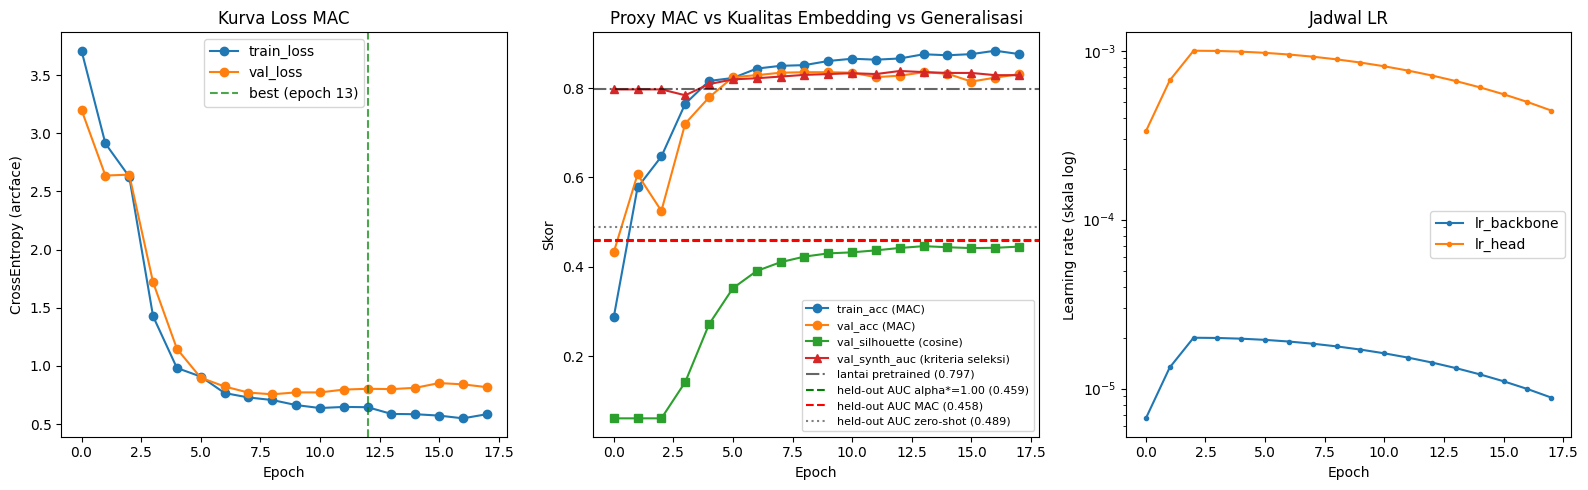

Plot tersimpan: training_curves_local_mac_opt.png


In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(history["train_loss"], marker="o", label="train_loss")
ax.plot(history["val_loss"], marker="o", label="val_loss")
if best_epoch >= 0:
    ax.axvline(best_epoch, color="green", ls="--", alpha=0.7, label=f"best (epoch {best_epoch+1})")
ax.set_xlabel("Epoch"); ax.set_ylabel(f"CrossEntropy ({CFG.mac_head})")
ax.set_title("Kurva Loss MAC")
ax.legend()

ax = axes[1]
ax.plot(history["train_acc"], marker="o", label="train_acc (MAC)")
ax.plot(history["val_acc"], marker="o", label="val_acc (MAC)")
if CFG.mac_track_silhouette:
    ax.plot(history["val_silhouette"], marker="s", label="val_silhouette (cosine)")
ax.plot(history["val_synth_auc"], marker="^", label="val_synth_auc (kriteria seleksi)")
ax.axhline(_sel0, color="black", ls="-.", alpha=0.6, label=f"lantai pretrained ({_sel0:.3f})")
ax.axhline(auc_embedding_wise, color="green", ls="--",
           label=f"held-out AUC alpha*={BEST_ALPHA:.2f} ({auc_embedding_wise:.3f})")
ax.axhline(auc_embedding_finetuned, color="red", ls="--",
           label=f"held-out AUC MAC ({auc_embedding_finetuned:.3f})")
ax.axhline(auc_embedding_original, color="gray", ls=":",
           label=f"held-out AUC zero-shot ({auc_embedding_original:.3f})")
ax.set_xlabel("Epoch"); ax.set_ylabel("Skor")
ax.set_title("Proxy MAC vs Kualitas Embedding vs Generalisasi")
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(history["lr_backbone"], marker=".", label="lr_backbone")
ax.plot(history["lr_head"], marker=".", label="lr_head")
ax.set_yscale("log")
ax.set_xlabel("Epoch"); ax.set_ylabel("Learning rate (skala log)")
ax.set_title("Jadwal LR")
ax.legend()

plt.tight_layout()
plt.savefig(f"training_curves_{RUN_TAG}.png", dpi=150)
plt.show()
print(f"Plot tersimpan: training_curves_{RUN_TAG}.png")


# Bagian IV — Walkthrough Referensi: Alur Inferensi Penuh (Blok B–E)
## 19. Blok B — Encoder (Sudah Ada)


## 20. Blok C — Kalibrasi Instance-Specific


In [26]:
from dataclasses import dataclass as _dc


@_dc
class MachineBaseline:
    machine_label: str
    n_windows: int
    embeddings: np.ndarray
    backend_stats: Dict[str, Dict[str, float]]
    calibration_quality: str


def embed_windows(windows: List[np.ndarray]) -> np.ndarray:
    batch = torch.stack([torch.from_numpy(w.astype(np.float32)) for w in windows]).to(device)
    return model.embed(batch).cpu().numpy()


def build_baseline(embeddings: np.ndarray, machine_label: str, cfg: Config) -> MachineBaseline:
    n = embeddings.shape[0]
    quality = "baik" if n >= cfg.min_calibration_windows else "rendah"

    raw_by_backend: Dict[str, list] = {name: [] for name in ("cosine", "mahalanobis", "knn", "pca")}
    # Estimasi mu/sigma di-subsample: ini statistik normalisasi, bukan jalur skoring,
    # jadi memakai 60 sampel leave-one-out alih-alih n memberi angka yang sama secara
    # praktis dengan biaya O(n) SVD, bukan O(n^2). Penting sejak pooling mean_std
    # menaikkan dimensi embedding jadi 1536.
    idx_pool = np.arange(n)
    if n > cfg.baseline_loo_max:
        idx_pool = np.random.RandomState(cfg.seed).choice(n, cfg.baseline_loo_max, replace=False)
    for i in idx_pool:
        bank_loo = np.delete(embeddings, i, axis=0)
        if len(bank_loo) < 2:
            continue
        raw = compute_all_backend_scores(embeddings[i], bank_loo, cfg)
        for name, val in raw.items():
            raw_by_backend[name].append(val)

    backend_stats: Dict[str, Dict[str, float]] = {}
    for name, scores in raw_by_backend.items():
        arr = np.array(scores) if scores else np.array([0.0])
        backend_stats[name] = {"mu": float(arr.mean()), "sigma": float(arr.std() + 1e-8)}

    return MachineBaseline(
        machine_label=machine_label, n_windows=n, embeddings=embeddings.astype(np.float32),
        backend_stats=backend_stats, calibration_quality=quality,
    )


print("Blok C (kalibrasi) siap. Catatan: compute_all_backend_scores didefinisikan di Bagian 21 -- "
      "jalankan Bagian 21 sebelum memanggil build_baseline().")

Blok C (kalibrasi) siap. Catatan: compute_all_backend_scores didefinisikan di Bagian 21 -- jalankan Bagian 21 sebelum memanggil build_baseline().


## 21. Blok D — Multi-Backend Scoring & Fusi


In [27]:
def _cosine_score(query: np.ndarray, bank: np.ndarray) -> float:
    bank_norm = bank / (np.linalg.norm(bank, axis=1, keepdims=True) + 1e-12)
    q_norm = query / (np.linalg.norm(query) + 1e-12)
    sims = bank_norm @ q_norm
    return float(1.0 - sims.max())


def _mahalanobis_score(query: np.ndarray, bank: np.ndarray, shrinkage: float) -> float:
    mu = bank.mean(axis=0)
    cov = np.cov(bank, rowvar=False)
    d = cov.shape[0]
    cov_shrunk = (1 - shrinkage) * cov + shrinkage * (np.trace(cov) / d) * np.eye(d)
    try:
        inv = np.linalg.inv(cov_shrunk)
    except np.linalg.LinAlgError:
        inv = np.linalg.pinv(cov_shrunk)
    diff = query - mu
    return float(np.sqrt(max(diff @ inv @ diff.T, 0.0)))


def _knn_density_score(query: np.ndarray, bank: np.ndarray, k: int) -> float:
    dists = np.linalg.norm(bank - query, axis=1)
    k_eff = max(1, min(k, len(dists)))
    return float(np.sort(dists)[:k_eff].mean())


def _pca_residual_score(query: np.ndarray, bank: np.ndarray, variance_target: float) -> float:
    mu = bank.mean(axis=0)
    centered = bank - mu
    _, s, vt = np.linalg.svd(centered, full_matrices=False)
    total = np.sum(s ** 2)
    if total < 1e-12:
        return 0.0
    var_ratio = (s ** 2) / total
    cum = np.cumsum(var_ratio)
    n_components = min(max(1, int(np.searchsorted(cum, variance_target) + 1)), vt.shape[0])
    components = vt[:n_components]
    q_centered = query - mu
    proj = components.T @ (components @ q_centered)
    return float(np.linalg.norm(q_centered - proj))


def compute_all_backend_scores(query: np.ndarray, bank: np.ndarray, cfg: Config) -> Dict[str, float]:
    if len(bank) < 2:
        raise ValueError(f"Memory bank terlalu kecil ({len(bank)} embedding).")
    return {
        "cosine": _cosine_score(query, bank),
        "mahalanobis": _mahalanobis_score(query, bank, cfg.mahalanobis_shrinkage),
        "knn": _knn_density_score(query, bank, cfg.knn_k),
        "pca": _pca_residual_score(query, bank, cfg.pca_variance_target),
    }


def fuse_scores(raw_scores: Dict[str, float], backend_stats: Dict[str, Dict[str, float]]) -> float:
    z_scores = []
    for name, raw in raw_scores.items():
        stats = backend_stats[name]
        z_scores.append((raw - stats["mu"]) / stats["sigma"])
    return float(min(z_scores))


print("Blok D (scoring) siap.")

Blok D (scoring) siap.


## 22. Blok E — Keputusan & Interpretasi


In [28]:
from scipy import stats as scipy_stats

DISCLAIMER = "Alat bantu triase, bukan diagnosis mengikat -- tetap perlu inspeksi teknisi."


@_dc
class HealthCard:
    status: str
    z_score: float
    calibration_quality: str
    dominant_indicator: Optional[str]
    disclaimer: str


def _dsp_features(w: np.ndarray) -> np.ndarray:
    kurt = float(scipy_stats.kurtosis(w))
    crest = float(np.max(np.abs(w)) / (np.sqrt(np.mean(w ** 2)) + 1e-12))
    spec = np.abs(np.fft.rfft(w))
    freqs = np.fft.rfftfreq(len(w))
    centroid = float(np.sum(freqs * spec) / (np.sum(spec) + 1e-12))
    return np.array([kurt, crest, centroid])


def _dsp_attribution(window: np.ndarray, calibration_windows: List[np.ndarray]) -> str:
    names = ["kurtosis", "crest_factor", "spectral_centroid"]
    test_feat = _dsp_features(window)
    calib_feats = np.array([_dsp_features(w) for w in calibration_windows])
    mu = calib_feats.mean(axis=0)
    sigma = calib_feats.std(axis=0) + 1e-8
    z = np.abs((test_feat - mu) / sigma)
    return names[int(np.argmax(z))]


def decide(
    window: np.ndarray,
    window_embedding: np.ndarray,
    baseline: MachineBaseline,
    cfg: Config,
    calibration_windows: Optional[List[np.ndarray]] = None,
) -> HealthCard:
    if baseline.calibration_quality == "rendah":
        return HealthCard("KALIBRASI_KURANG", float("nan"), baseline.calibration_quality, None, DISCLAIMER)

    raw_scores = compute_all_backend_scores(window_embedding, baseline.embeddings, cfg)
    z = fuse_scores(raw_scores, baseline.backend_stats)

    if z >= cfg.z_critical:
        status = "CRITICAL"
    elif z >= cfg.z_warning:
        status = "WARNING"
    else:
        status = "NORMAL"

    dominant = None
    if status != "NORMAL" and calibration_windows:
        dominant = _dsp_attribution(window, calibration_windows)

    return HealthCard(status, z, baseline.calibration_quality, dominant, DISCLAIMER)


print("Blok E (keputusan) siap.")

Blok E (keputusan) siap.


## 23. 🎬 DEMO — Alur E2E Nyata: Kalibrasi → Inspeksi → Kartu Hasil


In [29]:
import random as _random
_rng_demo = _random.Random(CFG.seed)

demo_calib_paths = train_df[train_df.label == "normal"]["path"].tolist()[:20]
demo_test_normal = val_df[val_df.label == "normal"]["path"].tolist()
demo_test_abnormal = val_df[val_df.label == "abnormal"]["path"].tolist()

assert len(demo_calib_paths) >= 5, "Tidak cukup klip normal untuk demo kalibrasi."
assert demo_test_normal, "Tidak ada klip normal di val_df untuk demo."
assert demo_test_abnormal, "Tidak ada klip abnormal di val_df untuk demo."

demo_test_normal_path = demo_test_normal[0]
demo_test_abnormal_path = demo_test_abnormal[0]

print("=" * 70)
print("TAHAP 1: KALIBRASI")
print("=" * 70)
print(f"Memakai {len(demo_calib_paths)} klip normal sebagai sesi kalibrasi...")

calib_windows_demo: List[np.ndarray] = []
for p in demo_calib_paths:
    raw = load_audio(p, CFG)
    print(f"  {Path(p).name}: durasi mentah {len(raw)/CFG.sr:.1f}s", end="")
    xc = condition(raw, CFG.sr, CFG)
    windows = make_windows(xc, CFG.sr, CFG)
    print(f" -> {len(windows)} window setelah kondisi+windowing")
    calib_windows_demo.extend(windows)

print(f"\nTotal window kalibrasi: {len(calib_windows_demo)}")
calib_embeddings_demo = embed_windows(calib_windows_demo)
print(f"Embedding: shape {calib_embeddings_demo.shape}")

baseline_demo = build_baseline(calib_embeddings_demo, "Demo Machine", CFG)
print(f"MachineBaseline dibangun: n_windows={baseline_demo.n_windows}, "
      f"kualitas={baseline_demo.calibration_quality}")
print("Statistik backend (mu, sigma) hasil self-score leave-one-out:")
for name, stats in baseline_demo.backend_stats.items():
    print(f"  {name:12s}: mu={stats['mu']:.4f}  sigma={stats['sigma']:.4f}")

TAHAP 1: KALIBRASI
Memakai 20 klip normal sebagai sesi kalibrasi...
  00000314.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000943.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000554.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000919.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000256.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000613.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000155.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000172.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000039.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000638.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000879.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000835.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000576.wav: durasi mentah 10.0s -> 9 win

In [30]:
def run_inspection_demo(audio_path: str, label_gt: str) -> None:
    print("=" * 70)
    print(f"TAHAP 2: INSPEKSI -- {Path(audio_path).name}  (ground truth: {label_gt})")
    print("=" * 70)
    raw = load_audio(audio_path, CFG)
    print(f"1. Audio dimuat: {len(raw)/CFG.sr:.1f} detik, {CFG.sr}Hz")

    xc = condition(raw, CFG.sr, CFG)
    print(f"2. Setelah condition() [bandpass+notch+normalize"
          f"{'+denoise' if CFG.enable_denoise else ''}]: peak={np.max(np.abs(xc)):.3f}")

    windows = make_windows(xc, CFG.sr, CFG)
    print(f"3. Setelah make_windows(): {len(windows)} window {CFG.window_sec}s (hop {CFG.hop_sec}s)")
    if not windows:
        print("   Tidak ada window valid -- quality gate menolak semua window. Berhenti.")
        return
    window = windows[0]

    embedding = embed_windows([window])[0]
    print(f"4. Setelah encoder.embed(): vektor dim={embedding.shape[0]}, "
          f"norm={np.linalg.norm(embedding):.3f} (harus ~1.0, L2-normalized)")

    raw_scores = compute_all_backend_scores(embedding, baseline_demo.embeddings, CFG)
    print("5. Skor mentah 4 backend terhadap memory bank kalibrasi:")
    for name, val in raw_scores.items():
        print(f"     {name:12s}: {val:.4f}")

    z = fuse_scores(raw_scores, baseline_demo.backend_stats)
    print(f"6. Setelah z-normalisasi + fusi MINIMUM: z = {z:.3f}  "
          f"(ambang WARNING={CFG.z_warning}, CRITICAL={CFG.z_critical})")

    card = decide(window, embedding, baseline_demo, CFG, calibration_windows=calib_windows_demo)
    print(f"\n>>> HASIL AKHIR: status={card.status}  z={card.z_score:.3f}  "
          f"indikator_dominan={card.dominant_indicator}")
    print(f">>> {card.disclaimer}")
    match = "COCOK" if (card.status == "NORMAL") == (label_gt == "normal") else "TIDAK COCOK"
    print(f">>> vs ground truth ({label_gt}): {match}")


run_inspection_demo(demo_test_normal_path, "normal")
print()
run_inspection_demo(demo_test_abnormal_path, "abnormal")

TAHAP 2: INSPEKSI -- 00000238.wav  (ground truth: normal)
1. Audio dimuat: 10.0 detik, 16000Hz
2. Setelah condition() [bandpass+notch+normalize]: peak=1.000
3. Setelah make_windows(): 9 window 2.0s (hop 1.0s)
4. Setelah encoder.embed(): vektor dim=1536, norm=1.000 (harus ~1.0, L2-normalized)
5. Skor mentah 4 backend terhadap memory bank kalibrasi:
     cosine      : 0.0105
     mahalanobis : 11.2974
     knn         : 0.1745
     pca         : 0.1132
6. Setelah z-normalisasi + fusi MINIMUM: z = -1.202  (ambang WARNING=3.0, CRITICAL=6.0)

>>> HASIL AKHIR: status=NORMAL  z=-1.202  indikator_dominan=None
>>> Alat bantu triase, bukan diagnosis mengikat -- tetap perlu inspeksi teknisi.
>>> vs ground truth (normal): COCOK

TAHAP 2: INSPEKSI -- 00000238.wav  (ground truth: abnormal)
1. Audio dimuat: 10.0 detik, 16000Hz
2. Setelah condition() [bandpass+notch+normalize]: peak=1.000
3. Setelah make_windows(): 9 window 2.0s (hop 1.0s)
4. Setelah encoder.embed(): vektor dim=1536, norm=1.000 (harus

# Bagian V — Ablasi B0 → B1 → B2 vs Baseline Resmi
## 24. Konfigurasi Evaluasi & Anchor Baseline Resmi


In [31]:
N_SEEDS_ABLATION = 3
MAX_TEST_CLIPS_PER_CLASS = 150

OFFICIAL_HITACHI_BASELINE_MINUS6DB = {
    "id_00": 0.5757, "id_02": 0.6401, "id_04": 0.5715,
}
anchor = sum(OFFICIAL_HITACHI_BASELINE_MINUS6DB.values()) / len(OFFICIAL_HITACHI_BASELINE_MINUS6DB)
print(f"Anchor baseline resmi (fan -6dB, rata-rata): {anchor:.4f}")
if DATASET_MODE != "mimii":
    print("PERHATIAN: DATASET_MODE bukan 'mimii' -- perbandingan ke baseline resmi Hitachi "
          "TIDAK APPLICABLE (baseline itu diukur khusus untuk unduhan Zenodo terverifikasi "
          "checksum; provenance dataset Anda saat ini tidak diverifikasi setara). "
          "Bagian ablasi di bawah tetap jalan untuk mengukur delta ANTAR TAHAP di data Anda "
          "sendiri (termasuk AUC di held-out unit kalau USES_HELDOUT_UNIT), tapi jangan "
          "bandingkan angkanya langsung ke tabel Hitachi.")

print("\n--- Dua protokol evaluasi yang dilaporkan terpisah ---")
print("P-A 'unit sendiri' : adapter PERNAH melihat unit ini (klip lain dari unit yang sama),")
print("                     tapi klip tesnya dicadangkan dan tidak pernah dilatihkan.")
print(f"                     Unit: {SEEN_MACHINE_IDS}")
print("P-B 'unit baru'    : adapter TIDAK PERNAH melihat unit ini sama sekali. Ini yang")
print("                     mencerminkan kondisi deploy AUDIAX sebenarnya (adapter dilatih")
print("                     di mesin lain, mesin operator baru dan hanya dikalibrasi).")
print(f"                     Unit: {[m for m in sorted(MF.model_id.unique()) if m not in SEEN_MACHINE_IDS]}")
print("\nPERINGATAN SEED: N_SEEDS_ABLATION hanya mengacak pemilihan klip kalibrasi/tes,")
print("BUKAN seed training. Jadi auc_std yang dilaporkan adalah variasi terhadap pilihan")
print("klip, bukan variasi terhadap inisialisasi/urutan training.")


Anchor baseline resmi (fan -6dB, rata-rata): 0.5958
PERHATIAN: DATASET_MODE bukan 'mimii' -- perbandingan ke baseline resmi Hitachi TIDAK APPLICABLE (baseline itu diukur khusus untuk unduhan Zenodo terverifikasi checksum; provenance dataset Anda saat ini tidak diverifikasi setara). Bagian ablasi di bawah tetap jalan untuk mengukur delta ANTAR TAHAP di data Anda sendiri (termasuk AUC di held-out unit kalau USES_HELDOUT_UNIT), tapi jangan bandingkan angkanya langsung ke tabel Hitachi.

--- Dua protokol evaluasi yang dilaporkan terpisah ---
P-A 'unit sendiri' : adapter PERNAH melihat unit ini (klip lain dari unit yang sama),
                     tapi klip tesnya dicadangkan dan tidak pernah dilatihkan.
                     Unit: ['id_00', 'id_02', 'id_06']
P-B 'unit baru'    : adapter TIDAK PERNAH melihat unit ini sama sekali. Ini yang
                     mencerminkan kondisi deploy AUDIAX sebenarnya (adapter dilatih
                     di mesin lain, mesin operator baru dan hanya dikal

## 25. Fungsi Evaluasi Inti (Reuse Blok C/D dari Bagian 20-21)

Dua hal penting di sini:

1. **`exclude_paths`** — klip yang dipakai melatih adapter dibuang dari kandidat
   **tes**. Tanpa ini, unit yang ikut dilatihkan dinilai pada klip yang persis
   dilatihkan, dan AUC-nya mengukur hafalan, bukan deteksi.
2. **Metrik operasional** — selain AUC, tiap baris melaporkan pAUC (p=0.1,
   standar DCASE) dan perilaku pada ambang produksi (`fpr_warn`, `recall_warn`,
   `fpr_crit`, `recall_crit`). AUC meringkas seluruh kurva ROC termasuk daerah
   false-positive tinggi yang tidak akan pernah dipakai UMKM.

Tiga skema agregasi window→klip dihitung sekaligus dari embedding yang sama,
jadi menambah skema tidak menambah biaya encoder.


In [32]:
# --- Cache embedding -------------------------------------------------------
# Kenapa: B0, B1, tiga sel diagnostik Bagian 6b, dan ablasi jalur data Bagian 29b
# semuanya menjalankan BEATs pada window yang identik. Tanpa cache, encoder
# dijalankan ulang 5x atau lebih untuk data yang persis sama.
_EMB_CACHE: Dict[tuple, np.ndarray] = {}


def _config_fingerprint(cfg: Config) -> tuple:
    """Semua field cfg yang mengubah bentuk gelombang atau pembagian window.

    Kalau salah satu berubah, embedding lama tidak lagi valid dan harus dihitung ulang.
    """
    return (
        cfg.sr, cfg.audio_channel, cfg.normalize_mode, cfg.rms_target,
        cfg.enable_privacy_notch, cfg.enable_denoise,
        cfg.bp_low, cfg.bp_high, cfg.bp_order,
        cfg.notch_low, cfg.notch_high, cfg.notch_order,
        cfg.window_sec, cfg.hop_sec,
        cfg.min_duration_sec, cfg.min_snr_db, cfg.silence_rms, cfg.max_clipping_ratio,
    )


def clip_embeddings(
    path: str, embed_fn: Callable[[List[np.ndarray]], np.ndarray], embed_tag: str, cfg: Config,
) -> np.ndarray:
    """Embedding semua window valid dari satu klip. embed_tag membedakan encoder."""
    key = (embed_tag, _config_fingerprint(cfg), path)
    hit = _EMB_CACHE.get(key)
    if hit is not None:
        return hit
    windows = make_windows(condition(load_audio(path, cfg), cfg.sr, cfg), cfg.sr, cfg)
    emb = embed_fn(windows) if windows else np.zeros((0, 0), dtype=np.float32)
    _EMB_CACHE[key] = emb
    return emb


def clear_embedding_cache() -> None:
    _EMB_CACHE.clear()


# --- Agregasi skor window -> skor klip -------------------------------------
AGGREGATIONS: Tuple[str, ...] = ("mean", "max", "topk")
PRIMARY_AGG = "mean"  # dipakai tabel ringkasan; "mean" = perilaku lama


def aggregate_window_scores(window_z: List[float], name: str, cfg: Config) -> float:
    """Ringkas z per-window jadi satu z per klip.

    Kenapa ini diablasi: kerusakan bantalan sering INTERMITEN -- hanya sebagian
    window dalam satu klip 10 detik yang benar-benar anomali. "mean" (perilaku
    lama) menenggelamkan window-window itu di antara window normal, sedangkan
    "topk"/"max" tidak.
    """
    a = np.asarray(window_z, dtype=np.float64)
    if name == "mean":
        return float(a.mean())
    if name == "max":
        return float(a.max())
    if name == "topk":
        k = max(1, int(np.ceil(cfg.topk_frac * len(a))))
        return float(np.sort(a)[-k:].mean())
    raise ValueError(f"Agregasi tidak dikenal: {name!r} (pilih dari {AGGREGATIONS})")


# --- Metrik ----------------------------------------------------------------
_METRIC_KEYS = ("auc", "pauc", "fpr_warn", "recall_warn", "fpr_crit", "recall_crit")


def score_metrics(labels: List[int], scores: List[float], cfg: Config) -> Dict[str, float]:
    """AUC + pAUC + perilaku pada ambang operasional yang sebenarnya dipakai.

    Kenapa lebih dari AUC: AUC meringkas SELURUH kurva ROC, termasuk daerah
    false-positive tinggi yang tidak akan pernah dipakai UMKM. pAUC (p=0.1,
    standar DCASE) hanya melihat daerah FPR rendah yang relevan. Dan fpr_warn /
    recall_warn menjawab pertanyaan yang benar-benar akan ditanya juri: pada
    ambang z_warning yang dipasang di produksi, berapa alarm palsunya dan berapa
    kerusakan yang tertangkap? Itu tidak bisa dibaca dari AUC.
    """
    if len(set(labels)) < 2:
        return {k: float("nan") for k in _METRIC_KEYS}
    lab = np.asarray(labels)
    sc = np.asarray(scores, dtype=np.float64)
    out = {
        "auc": float(roc_auc_score(lab, sc)),
        "pauc": float(roc_auc_score(lab, sc, max_fpr=cfg.pauc_max_fpr)),
    }
    for tag, thr in (("warn", cfg.z_warning), ("crit", cfg.z_critical)):
        out[f"fpr_{tag}"] = float(np.mean(sc[lab == 0] >= thr))
        out[f"recall_{tag}"] = float(np.mean(sc[lab == 1] >= thr))
    return out


# --- Evaluasi satu unit ----------------------------------------------------
def evaluate_machine(
    machine_id: str,
    manifest: pd.DataFrame,
    embed_fn: Callable[[List[np.ndarray]], np.ndarray],
    embed_tag: str,
    cfg: Config,
    n_calib: int,
    seed: int,
    max_test_per_class: int,
    backends: Optional[list] = None,
    exclude_paths: Optional[set] = None,
    aggregations: Tuple[str, ...] = AGGREGATIONS,
) -> Dict[str, Dict[str, float]]:
    """Kalibrasi pada klip normal unit ini, lalu skor klip tes unit yang sama.

    exclude_paths: klip yang dipakai melatih adapter. Klip-klip itu dibuang dari
    kandidat TES (bukan dari kandidat kalibrasi -- di lapangan, rekaman kalibrasi
    memang berasal dari mesin yang sama dan boleh saja "sudah dikenal"; yang tidak
    boleh adalah menilai deteksi pada klip yang label anomalinya sudah dilatihkan).
    Untuk tahap zero-shot (B0/B1) tidak ada yang dilatih, jadi exclude_paths=None.

    Mengembalikan metrik untuk SETIAP skema agregasi sekaligus -- semuanya memakai
    embedding yang sama, jadi tambahan skema agregasi tidak menambah biaya encoder.
    """
    rng = np.random.RandomState(seed)
    sub = manifest[manifest.model_id == machine_id]
    normal = sub[sub.label == "normal"]["path"].tolist()
    abnormal = sub[sub.label == "abnormal"]["path"].tolist()
    rng.shuffle(normal)
    rng.shuffle(abnormal)

    excl = set(exclude_paths or ())

    # Kalibrasi diambil LEBIH DULU, dan diutamakan dari klip yang justru sudah
    # dilihat adapter. Kenapa: klip "bersih" itu sumber daya langka (cuma
    # per_unit_test_frac dari tiap unit seen), dan semuanya lebih berguna sebagai
    # klip TES. Memakainya untuk kalibrasi hanya akan mengecilkan set tes tanpa
    # manfaat -- rekaman kalibrasi di lapangan memang berasal dari mesin yang sama
    # dan tidak harus "belum pernah dilihat". Kalau tidak ada klip ter-exclude
    # (tahap zero-shot B0/B1/29b), pool-nya jatuh kembali ke seluruh klip normal,
    # persis perilaku lama.
    calib_pool = [p for p in normal if p in excl] or normal
    calib_paths = calib_pool[:n_calib]
    calib_set = set(calib_paths)

    normal_clean = [p for p in normal if p not in excl and p not in calib_set]
    abnormal_clean = [p for p in abnormal if p not in excl and p not in calib_set]

    test_normal = normal_clean[:max_test_per_class]
    test_abnormal = abnormal_clean[:max_test_per_class]
    if not test_normal or not test_abnormal:
        raise ValueError(
            f"[{machine_id}] Tidak cukup klip tes bersih setelah exclude_paths "
            f"(normal={len(test_normal)}, abnormal={len(test_abnormal)})."
        )

    calib_parts = [clip_embeddings(p, embed_fn, embed_tag, cfg) for p in calib_paths]
    calib_parts = [e for e in calib_parts if len(e) > 0]
    if not calib_parts:
        raise ValueError(f"[{machine_id}] Tidak ada window kalibrasi yang lolos quality gate.")
    calib_emb = np.concatenate(calib_parts, axis=0)
    if len(calib_emb) < cfg.min_calibration_windows:
        raise ValueError(f"[{machine_id}] Cuma {len(calib_emb)} window kalibrasi.")

    baseline = build_baseline(calib_emb, machine_id, cfg)
    stats_subset = {k: baseline.backend_stats[k] for k in backends} if backends is not None else None

    test_paths = test_normal + test_abnormal
    test_labels = [0] * len(test_normal) + [1] * len(test_abnormal)

    scores_by_agg: Dict[str, List[float]] = {a: [] for a in aggregations}
    labels: List[int] = []
    for p, y in zip(test_paths, test_labels):
        emb = clip_embeddings(p, embed_fn, embed_tag, cfg)
        if len(emb) == 0:
            continue
        window_z = []
        for e in emb:
            raw = compute_all_backend_scores(e, baseline.embeddings, cfg)
            if backends is not None:
                raw = {k: v for k, v in raw.items() if k in backends}
                window_z.append(fuse_scores(raw, stats_subset))
            else:
                window_z.append(fuse_scores(raw, baseline.backend_stats))
        for a in aggregations:
            scores_by_agg[a].append(aggregate_window_scores(window_z, a, cfg))
        labels.append(y)

    extra = {
        "n_test_normal": float(labels.count(0)),
        "n_test_abnormal": float(labels.count(1)),
        "n_calib_windows": float(len(calib_emb)),
    }
    return {a: {**score_metrics(labels, scores_by_agg[a], cfg), **extra} for a in aggregations}


def evaluate_stage(
    stage_name: str,
    manifest: pd.DataFrame,
    machine_ids: list,
    embed_fn: Callable[[List[np.ndarray]], np.ndarray],
    embed_tag: str,
    cfg: Config,
    backends: Optional[list] = None,
    exclude_paths: Optional[set] = None,
    n_calib: int = 25,
    n_seeds: Optional[int] = None,
    max_test_per_class: Optional[int] = None,
    aggregations: Tuple[str, ...] = AGGREGATIONS,
    verbose: bool = True,
) -> pd.DataFrame:
    n_seeds = N_SEEDS_ABLATION if n_seeds is None else n_seeds
    max_test = MAX_TEST_CLIPS_PER_CLASS if max_test_per_class is None else max_test_per_class
    rows = []
    for mid in machine_ids:
        per_agg: Dict[str, Dict[str, list]] = {a: defaultdict(list) for a in aggregations}
        for seed in range(n_seeds):
            res = evaluate_machine(
                mid, manifest, embed_fn, embed_tag, cfg, n_calib, seed, max_test,
                backends=backends, exclude_paths=exclude_paths, aggregations=aggregations,
            )
            for a, metrics in res.items():
                for k, v in metrics.items():
                    per_agg[a][k].append(v)
            if verbose:
                print(f"  [{stage_name}] {mid} seed={seed}: "
                      + "  ".join(f"AUC({a})={res[a]['auc']:.4f}" for a in aggregations))
        for a in aggregations:
            row = {
                "stage": stage_name,
                "machine_id": mid,
                "agg_mode": a,
                "unit_seen_by_adapter": mid in SEEN_MACHINE_IDS,
            }
            for k, vals in per_agg[a].items():
                row[f"{k}_mean"] = float(np.nanmean(vals))
            row["auc_std"] = float(np.nanstd(per_agg[a]["auc"]))
            rows.append(row)
    return pd.DataFrame(rows)


def primary(df: pd.DataFrame) -> pd.DataFrame:
    """Baris dengan agregasi utama saja -- supaya tabel ringkasan tetap satu baris per unit."""
    return df[df["agg_mode"] == PRIMARY_AGG]


print(f"Fungsi evaluasi siap. Agregasi diuji: {AGGREGATIONS} (utama: {PRIMARY_AGG}). "
      f"Metrik per baris: {_METRIC_KEYS}.")


Fungsi evaluasi siap. Agregasi diuji: ('mean', 'max', 'topk') (utama: mean). Metrik per baris: ('auc', 'pauc', 'fpr_warn', 'recall_warn', 'fpr_crit', 'recall_crit').


## 26. B0 — Zero-Shot BEATs + Cosine NN Saja


In [33]:
def embed_fn_zeroshot(windows: List[np.ndarray]) -> np.ndarray:
    batch = torch.stack([torch.from_numpy(w.astype(np.float32)) for w in windows]).to(device)
    return embed_orig(batch).cpu().numpy()


ALL_MACHINE_IDS = sorted(MF.model_id.unique())
print(f"Evaluasi B0 pada machine IDs: {ALL_MACHINE_IDS}")

# exclude_paths=None: B0 memakai BEATs pretrained apa adanya, tidak ada yang pernah
# dilatih, jadi tidak ada klip yang perlu dikecualikan.
results_b0 = evaluate_stage(
    "B0_zeroshot_cosine", MF, ALL_MACHINE_IDS, embed_fn_zeroshot, "zeroshot", CFG,
    backends=["cosine"], exclude_paths=None,
)
print(primary(results_b0).round(4).to_string(index=False))
b0_mean = primary(results_b0)["auc_mean"].mean()
print(f"\nRata-rata AUC B0 (agg={PRIMARY_AGG}): {b0_mean:.4f}")


Evaluasi B0 pada machine IDs: ['id_00', 'id_02', 'id_04', 'id_06']
  [B0_zeroshot_cosine] id_00 seed=0: AUC(mean)=0.5826  AUC(max)=0.5779  AUC(topk)=0.5771
  [B0_zeroshot_cosine] id_00 seed=1: AUC(mean)=0.5668  AUC(max)=0.5631  AUC(topk)=0.5670
  [B0_zeroshot_cosine] id_00 seed=2: AUC(mean)=0.5452  AUC(max)=0.5388  AUC(topk)=0.5404
  [B0_zeroshot_cosine] id_02 seed=0: AUC(mean)=0.5848  AUC(max)=0.5714  AUC(topk)=0.5737
  [B0_zeroshot_cosine] id_02 seed=1: AUC(mean)=0.6246  AUC(max)=0.5936  AUC(topk)=0.5998
  [B0_zeroshot_cosine] id_02 seed=2: AUC(mean)=0.5574  AUC(max)=0.5275  AUC(topk)=0.5298
  [B0_zeroshot_cosine] id_04 seed=0: AUC(mean)=0.5095  AUC(max)=0.4797  AUC(topk)=0.4870
  [B0_zeroshot_cosine] id_04 seed=1: AUC(mean)=0.5462  AUC(max)=0.5292  AUC(topk)=0.5318
  [B0_zeroshot_cosine] id_04 seed=2: AUC(mean)=0.5352  AUC(max)=0.5148  AUC(topk)=0.5224
  [B0_zeroshot_cosine] id_06 seed=0: AUC(mean)=0.7097  AUC(max)=0.6506  AUC(topk)=0.6635
  [B0_zeroshot_cosine] id_06 seed=1: AUC(me

### 26b. Diagnostik: Seberapa Mirip Unit Satu Sama Lain?

Menguji secara empiris klaim bahwa unit-unit MIMII berpasangan (mis. `id_00`
mirip `id_04`, `id_02` mirip `id_06`). Kalau benar, unit yang berpasangan akan
saling menjadi tetangga terdekat di ruang embedding, dan jarak antar-pasangan
akan kecil dibanding sebaran di dalam unit itu sendiri.

Dihitung dari embedding **zero-shot** (tanpa training apa pun), jadi hasilnya
tidak bisa dipengaruhi oleh pilihan split.


  id_00: 25 klip -> 225 window, sebaran dalam-unit = 0.0366
  id_02: 25 klip -> 225 window, sebaran dalam-unit = 0.0302
  id_04: 25 klip -> 225 window, sebaran dalam-unit = 0.0385
  id_06: 25 klip -> 225 window, sebaran dalam-unit = 0.0304

Jarak cosine ANTAR-CENTROID unit (makin kecil = makin mirip):
        id_00   id_02   id_04   id_06
id_00 -0.0000  0.0067  0.0067  0.0192
id_02  0.0067  0.0000  0.0051  0.0163
id_04  0.0067  0.0051  0.0000  0.0147
id_06  0.0192  0.0163  0.0147  0.0000

Sebaran DALAM-unit (rata-rata jarak klip normal ke centroid unitnya sendiri):
  id_00: 0.0366
  id_02: 0.0302
  id_04: 0.0385
  id_06: 0.0304

Tetangga terdekat tiap unit:
  id_00 -> id_04  (jarak 0.0067; 0.18x sebaran dalam-unit id_00)
  id_02 -> id_04  (jarak 0.0051; 0.17x sebaran dalam-unit id_02)
  id_04 -> id_02  (jarak 0.0051; 0.13x sebaran dalam-unit id_04)
  id_06 -> id_04  (jarak 0.0147; 0.49x sebaran dalam-unit id_06)

Uji hipotesis pasangan (id_00<->id_04, id_02<->id_06): 1/4 unit tetangga 

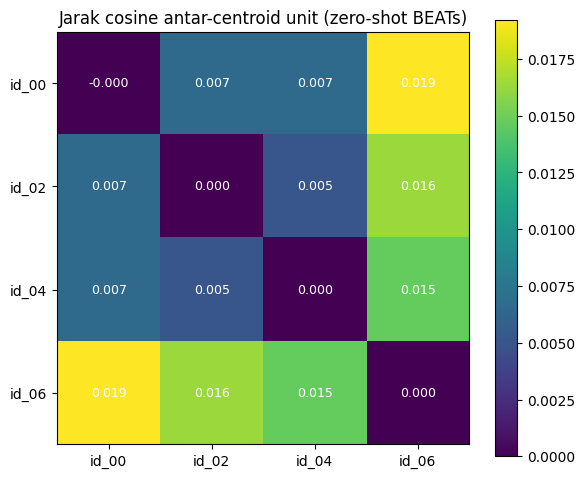


Tersimpan: unit_similarity_local_mac_opt.csv / .png


In [34]:
import matplotlib.pyplot as plt

N_CLIPS_CENTROID = 25

centroids: Dict[str, np.ndarray] = {}
intra_spread: Dict[str, float] = {}

for mid in ALL_MACHINE_IDS:
    paths = MF[(MF.model_id == mid) & (MF.label == "normal")]["path"].tolist()[:N_CLIPS_CENTROID]
    parts = [clip_embeddings(p, embed_fn_zeroshot, "zeroshot", CFG) for p in paths]
    embs = np.concatenate([e for e in parts if len(e) > 0], axis=0)
    c = embs.mean(axis=0)
    c = c / (np.linalg.norm(c) + 1e-12)
    centroids[mid] = c
    embs_n = embs / (np.linalg.norm(embs, axis=1, keepdims=True) + 1e-12)
    intra_spread[mid] = float(np.mean(1.0 - embs_n @ c))
    print(f"  {mid}: {len(paths)} klip -> {len(embs)} window, sebaran dalam-unit = {intra_spread[mid]:.4f}")

D = pd.DataFrame(index=ALL_MACHINE_IDS, columns=ALL_MACHINE_IDS, dtype=float)
for a in ALL_MACHINE_IDS:
    for b in ALL_MACHINE_IDS:
        D.loc[a, b] = float(1.0 - centroids[a] @ centroids[b])

print("\nJarak cosine ANTAR-CENTROID unit (makin kecil = makin mirip):")
print(D.round(4))
print("\nSebaran DALAM-unit (rata-rata jarak klip normal ke centroid unitnya sendiri):")
for mid, v in intra_spread.items():
    print(f"  {mid}: {v:.4f}")

print("\nTetangga terdekat tiap unit:")
pairs = {}
for mid in ALL_MACHINE_IDS:
    others = D.loc[mid].drop(mid)
    nearest = others.idxmin()
    pairs[mid] = nearest
    ratio = float(others.min()) / max(intra_spread[mid], 1e-12)
    print(f"  {mid} -> {nearest}  (jarak {others.min():.4f}; "
          f"{ratio:.2f}x sebaran dalam-unit {mid})")

hypothesis = {"id_00": "id_04", "id_04": "id_00", "id_02": "id_06", "id_06": "id_02"}
testable = [m for m in ALL_MACHINE_IDS if m in hypothesis and hypothesis[m] in ALL_MACHINE_IDS]
if testable:
    hits = [m for m in testable if pairs[m] == hypothesis[m]]
    print(f"\nUji hipotesis pasangan (id_00<->id_04, id_02<->id_06): "
          f"{len(hits)}/{len(testable)} unit tetangga terdekatnya sesuai hipotesis.")
    if len(hits) == len(testable):
        print("  -> HIPOTESIS DIDUKUNG: unit memang berpasangan di ruang embedding.")
    elif hits:
        print(f"  -> DIDUKUNG SEBAGIAN: sesuai untuk {hits}, tidak untuk yang lain.")
    else:
        print("  -> HIPOTESIS TIDAK DIDUKUNG: tidak ada unit yang tetangga terdekatnya "
              "sesuai pasangan yang dihipotesiskan.")
    print("  Catatan: dengan 4 unit dan 2 pasangan, SETIAP fold leave-one-unit-out "
          "tetap punya pasangannya di training (held-out id_04 -> id_00 ada di train; "
          "held-out id_02 -> id_06 ada di train). Jadi pairing tidak bisa menjelaskan "
          "kenapa satu fold jauh lebih buruk dari fold lain -- lihat juga bahwa AUC "
          "id_04 di sini berimpit dengan baseline resmi Hitachi untuk id_04 (0.5715), "
          "yang diukur TANPA training sama sekali.")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(D.values.astype(float), cmap="viridis")
ax.set_xticks(range(len(ALL_MACHINE_IDS))); ax.set_xticklabels(ALL_MACHINE_IDS)
ax.set_yticks(range(len(ALL_MACHINE_IDS))); ax.set_yticklabels(ALL_MACHINE_IDS)
for i in range(len(ALL_MACHINE_IDS)):
    for j in range(len(ALL_MACHINE_IDS)):
        ax.text(j, i, f"{D.values[i, j]:.3f}", ha="center", va="center", color="w", fontsize=9)
ax.set_title("Jarak cosine antar-centroid unit (zero-shot BEATs)")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(f"unit_similarity_{RUN_TAG}.png", dpi=150)
plt.show()
D.to_csv(f"unit_similarity_{RUN_TAG}.csv")
print(f"\nTersimpan: unit_similarity_{RUN_TAG}.csv / .png")


## 27. B1 — Zero-Shot BEATs + Multi-Backend Fusion


In [35]:
results_b1 = evaluate_stage(
    "B1_zeroshot_fusion", MF, ALL_MACHINE_IDS, embed_fn_zeroshot, "zeroshot", CFG,
    backends=None, exclude_paths=None,
)
print(primary(results_b1).round(4).to_string(index=False))
b1_mean = primary(results_b1)["auc_mean"].mean()
print(f"\nRata-rata AUC B1 (agg={PRIMARY_AGG}): {b1_mean:.4f}  (delta vs B0: {b1_mean - b0_mean:+.4f})")

print("\nPengaruh skema agregasi pada B1 (rata-rata seluruh unit):")
print(results_b1.groupby("agg_mode")[["auc_mean", "pauc_mean", "fpr_warn_mean", "recall_warn_mean"]]
      .mean().round(4).to_string())


  [B1_zeroshot_fusion] id_00 seed=0: AUC(mean)=0.5861  AUC(max)=0.5798  AUC(topk)=0.5778
  [B1_zeroshot_fusion] id_00 seed=1: AUC(mean)=0.5631  AUC(max)=0.5649  AUC(topk)=0.5686
  [B1_zeroshot_fusion] id_00 seed=2: AUC(mean)=0.5486  AUC(max)=0.5368  AUC(topk)=0.5394
  [B1_zeroshot_fusion] id_02 seed=0: AUC(mean)=0.5964  AUC(max)=0.5780  AUC(topk)=0.5794
  [B1_zeroshot_fusion] id_02 seed=1: AUC(mean)=0.6351  AUC(max)=0.5980  AUC(topk)=0.6041
  [B1_zeroshot_fusion] id_02 seed=2: AUC(mean)=0.5619  AUC(max)=0.5312  AUC(topk)=0.5309
  [B1_zeroshot_fusion] id_04 seed=0: AUC(mean)=0.5183  AUC(max)=0.4855  AUC(topk)=0.4930
  [B1_zeroshot_fusion] id_04 seed=1: AUC(mean)=0.5458  AUC(max)=0.5244  AUC(topk)=0.5280
  [B1_zeroshot_fusion] id_04 seed=2: AUC(mean)=0.5358  AUC(max)=0.5100  AUC(topk)=0.5154
  [B1_zeroshot_fusion] id_06 seed=0: AUC(mean)=0.7226  AUC(max)=0.6511  AUC(topk)=0.6652
  [B1_zeroshot_fusion] id_06 seed=1: AUC(mean)=0.7100  AUC(max)=0.6558  AUC(topk)=0.6635
  [B1_zeroshot_fusion

### 6b. Diagnosa: Kenapa B1 (fusion) Nyaris Sama Dengan B0 (cosine saja)?


In [ ]:
N_SEEDS_DIAGNOSTIC = 1

backend_auc = {"cosine": primary(results_b0).set_index("machine_id")["auc_mean"]}
for backend_name in ("mahalanobis", "knn", "pca"):
    r = evaluate_stage(
        f"B1_diag_{backend_name}", MF, ALL_MACHINE_IDS, embed_fn_zeroshot, "zeroshot", CFG,
        backends=[backend_name], exclude_paths=None, n_seeds=N_SEEDS_DIAGNOSTIC, verbose=False,
    )
    backend_auc[backend_name] = primary(r).set_index("machine_id")["auc_mean"]

backend_auc_df = pd.DataFrame(backend_auc)
backend_auc_df["B1_fused_min"] = primary(results_b1).set_index("machine_id")["auc_mean"]
print("AUC per backend individual vs B1 (fusi minimum) -- n_calib=25, 1 seed diagnostik:")
print(backend_auc_df.round(4))
print(
    "\nKalau salah satu backend individual jauh lebih rendah dari cosine tapi "
    "B1_fused_min juga rendah (dekat backend terlemah, bukan dekat cosine), itu "
    "mengonfirmasi hipotesis: backend yang noisy di n_calib kecil menenggelamkan "
    "sinyal cosine lewat fusi minimum. Ini BUKAN indikasi untuk mengubah skema fusi "
    "(keputusan desain #5 tetap berlaku) -- tapi jadi alasan kuat untuk mendiskusikan "
    "menaikkan n_calib atau meninjau ulang backend mana yang layak dipakai, bukan "
    "diubah sepihak di notebook."
)
print(
    "\nCATATAN REDUNDANSI BACKEND: pada embedding yang sudah L2-normalized berlaku "
    "||a-b||^2 = 2 - 2*cos(a,b), sehingga _cosine_score (1 - max cosine ke bank) dan "
    "_knn_density_score (rata-rata jarak Euclid ke k tetangga) nyaris monoton satu sama "
    "lain. Artinya 'empat backend' efektif menyumbang sekitar dua sampai tiga sumber "
    "informasi independen, bukan empat. Korelasi di bawah mengukurnya langsung."
)
_corr = backend_auc_df[["cosine", "mahalanobis", "knn", "pca"]].corr(method="spearman")
print("\nKorelasi Spearman AUC antar-backend (antar-unit):")
print(_corr.round(3))


## 28. B2 — Backbone Fine-Tuned (Hasil Training Notebook Ini) + Multi-Backend


In [37]:
def embed_fn_finetuned(windows: List[np.ndarray]) -> np.ndarray:
    return embed_windows(windows)


# exclude_paths=ADAPTER_TRAIN_PATHS: buang klip yang dipakai melatih adapter dari
# kandidat TES. Tanpa ini, unit seen dinilai pada klip yang persis dilatihkan --
# itulah sebab AUC 0.95-0.99 di versi notebook sebelumnya, dan angka itu hafalan,
# bukan deteksi.
results_b2 = evaluate_stage(
    "B2_finetuned_fusion", MF, ALL_MACHINE_IDS, embed_fn_finetuned, EMBED_TAG_FT, CFG,
    backends=None, exclude_paths=ADAPTER_TRAIN_PATHS,
)
p_b2 = primary(results_b2)
print(p_b2.round(4).to_string(index=False))

b2_mean = p_b2["auc_mean"].mean()
print(f"\nRata-rata AUC B2 seluruh unit (agg={PRIMARY_AGG}): {b2_mean:.4f}  "
      f"(delta vs B1: {b2_mean - b1_mean:+.4f})")

print("\n" + "=" * 78)
print("ANGKA HEADLINE -- dipisah per protokol")
print("=" * 78)

p_b1 = primary(results_b1)
for label, mask_val in (("P-A unit sendiri (adapter pernah lihat unit ini)", True),
                        ("P-B unit baru  (adapter belum pernah lihat unit ini)", False)):
    sel_b2 = p_b2[p_b2.unit_seen_by_adapter == mask_val]
    sel_b1 = p_b1[p_b1.machine_id.isin(sel_b2.machine_id)]
    if not len(sel_b2):
        continue
    d = float(sel_b2.auc_mean.mean() - sel_b1.auc_mean.mean())
    print(f"\n{label}")
    print(f"  unit      : {list(sel_b2.machine_id)}")
    print(f"  AUC  B1   : {sel_b1.auc_mean.mean():.4f}   B2: {sel_b2.auc_mean.mean():.4f}   ({d:+.4f})")
    print(f"  pAUC B2   : {sel_b2.pauc_mean.mean():.4f}  (p={CFG.pauc_max_fpr})")
    print(f"  pada ambang z_warning={CFG.z_warning}: "
          f"FPR={sel_b2.fpr_warn_mean.mean():.3f}  recall={sel_b2.recall_warn_mean.mean():.3f}")
    print(f"  pada ambang z_critical={CFG.z_critical}: "
          f"FPR={sel_b2.fpr_crit_mean.mean():.3f}  recall={sel_b2.recall_crit_mean.mean():.3f}")

print("\nYang boleh dikutip di proposal sebagai klaim generalisasi adalah baris P-B.")
print("P-A menjawab pertanyaan berbeda (seberapa baik adapter melayani unit yang ikut")
print("dilatihkan), dan TIDAK mencerminkan kondisi deploy AUDIAX.")

if USES_HELDOUT_UNIT:
    b2_ho = p_b2[p_b2.machine_id == CFG.holdout_machine_id]
    b1_ho = p_b1[p_b1.machine_id == CFG.holdout_machine_id]
    if len(b2_ho) and len(b1_ho):
        d = float(b2_ho.auc_mean.iloc[0] - b1_ho.auc_mean.iloc[0])
        print(f"\nAUC B2 di held-out unit ({CFG.holdout_machine_id}): "
              f"{float(b2_ho.auc_mean.iloc[0]):.4f} (delta vs B1: {d:+.4f})")
        if DATASET_MODE == "mimii" and CFG.holdout_machine_id in OFFICIAL_HITACHI_BASELINE_MINUS6DB:
            print(f"  Baseline resmi Hitachi untuk unit ini: "
                  f"{OFFICIAL_HITACHI_BASELINE_MINUS6DB[CFG.holdout_machine_id]:.4f}")
        if d <= 0:
            print("CATATAN: fine-tuning TIDAK terbukti membantu di unit held-out -- laporkan apa adanya.")

print("\nPengaruh skema agregasi pada B2 (rata-rata seluruh unit):")
print(results_b2.groupby("agg_mode")[["auc_mean", "pauc_mean", "fpr_warn_mean", "recall_warn_mean"]]
      .mean().round(4).to_string())


  [B2_finetuned_fusion] id_00 seed=0: AUC(mean)=0.6407  AUC(max)=0.6141  AUC(topk)=0.6195
  [B2_finetuned_fusion] id_00 seed=1: AUC(mean)=0.6754  AUC(max)=0.6480  AUC(topk)=0.6587
  [B2_finetuned_fusion] id_00 seed=2: AUC(mean)=0.6231  AUC(max)=0.5887  AUC(topk)=0.6017
  [B2_finetuned_fusion] id_02 seed=0: AUC(mean)=0.6615  AUC(max)=0.6504  AUC(topk)=0.6544
  [B2_finetuned_fusion] id_02 seed=1: AUC(mean)=0.7359  AUC(max)=0.7350  AUC(topk)=0.7351
  [B2_finetuned_fusion] id_02 seed=2: AUC(mean)=0.6659  AUC(max)=0.6596  AUC(topk)=0.6637
  [B2_finetuned_fusion] id_04 seed=0: AUC(mean)=0.4907  AUC(max)=0.4747  AUC(topk)=0.4789
  [B2_finetuned_fusion] id_04 seed=1: AUC(mean)=0.5350  AUC(max)=0.5228  AUC(topk)=0.5281
  [B2_finetuned_fusion] id_04 seed=2: AUC(mean)=0.5254  AUC(max)=0.5096  AUC(topk)=0.5136
  [B2_finetuned_fusion] id_06 seed=0: AUC(mean)=0.8605  AUC(max)=0.8301  AUC(topk)=0.8389
  [B2_finetuned_fusion] id_06 seed=1: AUC(mean)=0.8694  AUC(max)=0.8481  AUC(topk)=0.8547
  [B2_fine

### 28b. B2-raw — Apa yang Sebenarnya Dibeli oleh Interpolasi

B2 di atas memakai `alpha*`. Sel ini menjalankan harness yang **persis sama** pada
`alpha=1` (fine-tune penuh, tanpa interpolasi) supaya kontribusi WiSE-FT bisa dikutip
sebagai satu angka delta, bukan diklaim tanpa bukti.

Untuk menghemat waktu, hanya unit **P-B** (belum pernah dilihat adapter) yang dijalankan
— itulah satu-satunya baris yang sah dikutip sebagai klaim generalisasi.


In [38]:
RUN_B2_RAW = True

_unseen_ids = [m for m in ALL_MACHINE_IDS if m not in SEEN_MACHINE_IDS]

if RUN_B2_RAW and BEST_ALPHA != 1.0 and _unseen_ids:
    model.backbone.load_state_dict(interpolate_backbone(PRETRAINED_SD, FINETUNED_SD, 1.0))
    model.eval()
    results_b2raw = evaluate_stage(
        "B2raw_finetuned_alpha1", MF, _unseen_ids, embed_fn_finetuned,
        f"finetuned_{TRAIN_OBJECTIVE}_a1.00", CFG,
        backends=None, exclude_paths=ADAPTER_TRAIN_PATHS,
    )
    # Kembalikan ke alpha* -- sel setelah ini harus memakai model yang dilaporkan.
    model.backbone.load_state_dict(interpolate_backbone(PRETRAINED_SD, FINETUNED_SD, BEST_ALPHA))
    model.eval()

    p_raw = primary(results_b2raw)
    p_wise = primary(results_b2)
    p_wise = p_wise[p_wise.machine_id.isin(_unseen_ids)]
    p_b1u = primary(results_b1)
    p_b1u = p_b1u[p_b1u.machine_id.isin(_unseen_ids)]

    print("\n" + "=" * 78)
    print("KONTRIBUSI WEIGHT INTERPOLATION -- unit P-B saja")
    print("=" * 78)
    print(f"  unit                 : {_unseen_ids}")
    print(f"  B1  (BEATs beku)     : AUC={p_b1u.auc_mean.mean():.4f}  pAUC={p_b1u.pauc_mean.mean():.4f}")
    print(f"  B2raw (alpha=1)      : AUC={p_raw.auc_mean.mean():.4f}  pAUC={p_raw.pauc_mean.mean():.4f}")
    print(f"  B2  (alpha*={BEST_ALPHA:.2f})     : AUC={p_wise.auc_mean.mean():.4f}  pAUC={p_wise.pauc_mean.mean():.4f}")
    print(f"  delta interpolasi    : {p_wise.auc_mean.mean() - p_raw.auc_mean.mean():+.4f} AUC")
    print(f"  delta vs BEATs beku  : {p_wise.auc_mean.mean() - p_b1u.auc_mean.mean():+.4f} AUC")
else:
    results_b2raw = pd.DataFrame()
    print("B2-raw dilewati (alpha*=1.0, jadi B2 SUDAH merupakan fine-tune penuh -- "
          "tidak ada yang perlu dibandingkan).")


B2-raw dilewati (alpha*=1.0, jadi B2 SUDAH merupakan fine-tune penuh -- tidak ada yang perlu dibandingkan).


## 29. (Opsional) Ablasi Denoise HPSS


In [39]:
denoise_target_id = CFG.holdout_machine_id if USES_HELDOUT_UNIT else ALL_MACHINE_IDS[0]
cfg_denoise_on = replace(CFG, enable_denoise=True)

_res_off = evaluate_machine(
    denoise_target_id, MF, embed_fn_finetuned, EMBED_TAG_FT, CFG,
    25, 0, MAX_TEST_CLIPS_PER_CLASS, exclude_paths=ADAPTER_TRAIN_PATHS,
)
_res_on = evaluate_machine(
    denoise_target_id, MF, embed_fn_finetuned, EMBED_TAG_FT, cfg_denoise_on,
    25, 0, MAX_TEST_CLIPS_PER_CLASS, exclude_paths=ADAPTER_TRAIN_PATHS,
)
auc_denoise_off = _res_off[PRIMARY_AGG]["auc"]
auc_denoise_on = _res_on[PRIMARY_AGG]["auc"]

print(f"Unit uji: {denoise_target_id} (agg={PRIMARY_AGG}, klip training adapter dikecualikan)")
print(f"AUC denoise OFF: {auc_denoise_off:.4f}  (pAUC {_res_off[PRIMARY_AGG]['pauc']:.4f})")
print(f"AUC denoise ON : {auc_denoise_on:.4f}  (pAUC {_res_on[PRIMARY_AGG]['pauc']:.4f})")
print(f"Delta: {auc_denoise_on - auc_denoise_off:+.4f}")
if auc_denoise_on <= auc_denoise_off:
    print("Denoise TIDAK terbukti membantu -- biarkan enable_denoise=False di ai/config.py.")
else:
    print("Denoise terbukti membantu -- pertimbangkan mengubah default, sebutkan angka ini di proposal.")


Unit uji: id_04 (agg=mean, klip training adapter dikecualikan)
AUC denoise OFF: 0.4907  (pAUC 0.4931)
AUC denoise ON : 0.5282  (pAUC 0.4933)
Delta: +0.0375
Denoise terbukti membantu -- pertimbangkan mengubah default, sebutkan angka ini di proposal.


## 29b. Ablasi Jalur Data (Tanpa Retraining)

Tiga keputusan preprocessing yang belum pernah diukur biayanya, plus skema
agregasi skor. Semuanya dievaluasi pada encoder **zero-shot** (B1: fusi 4
backend, tanpa fine-tuning) sehingga hasilnya tidak tercampur efek training.

| Faktor | Nilai | Kenapa diragukan |
|---|---|---|
| `audio_channel` | `None` (rata-rata 8 kanal) vs `0` (satu kanal) | MIMII = array melingkar 8 mikrofon; merata-ratakannya = beamforming naif + comb filtering |
| `normalize_mode` | `peak` vs `rms` | peak-normalize menghapus level absolut, padahal kenaikan amplitudo adalah tanda anomali langsung |
| `enable_privacy_notch` | `True` vs `False` | bandstop 300–3400 Hz membuang pita tempat harmonik blade-pass & sideband bearing berada |
| agregasi | `mean` / `max` / `topk` | anomali bantalan intermiten; `mean` menenggelamkan window yang benar-benar anomali |

Agregasi **tidak menambah biaya encoder** — ketiganya dihitung dari embedding
yang sama. Jadi yang benar-benar dijalankan hanya 8 kombinasi jalur data.


In [ ]:
RUN_DATAPATH_ABLATION = True

# Dikecilkan dari setelan ablasi utama supaya 8 kombinasi selesai dalam waktu wajar.
DP_SEEDS = 2
DP_MAX_TEST = 60
DP_N_CALIB = 25

if RUN_DATAPATH_ABLATION:
    dp_rows = []
    combos = [
        (ch, nm, notch)
        for ch in (None, 0)
        for nm in ("peak", "rms")
        for notch in (True, False)
    ]
    print(f"Menjalankan {len(combos)} kombinasi jalur data x {len(ALL_MACHINE_IDS)} unit "
          f"x {DP_SEEDS} seed (encoder zero-shot, fusi 4 backend).")
    print(f"Tiap kombinasi meng-encode ulang semua klip -- perkirakan beberapa menit per kombinasi.\n")

    for i, (ch, nm, notch) in enumerate(combos, 1):
        cfg_dp = replace(CFG, audio_channel=ch, normalize_mode=nm, enable_privacy_notch=notch)
        tag = (f"ch={'mean8' if ch is None else ch}|norm={nm}|notch={'on' if notch else 'off'}")
        clear_embedding_cache()  # kombinasi baru = bentuk gelombang baru
        df_dp = evaluate_stage(
            tag, MF, ALL_MACHINE_IDS, embed_fn_zeroshot, f"zeroshot|{tag}", cfg_dp,
            backends=None, exclude_paths=None, n_calib=DP_N_CALIB,
            n_seeds=DP_SEEDS, max_test_per_class=DP_MAX_TEST, verbose=False,
        )
        df_dp["audio_channel"] = "mean8" if ch is None else str(ch)
        df_dp["normalize_mode"] = nm
        df_dp["privacy_notch"] = "on" if notch else "off"
        dp_rows.append(df_dp)
        best = df_dp.groupby("agg_mode").auc_mean.mean()
        print(f"[{i}/{len(combos)}] {tag}: "
              + "  ".join(f"AUC({a})={v:.4f}" for a, v in best.items()))

    clear_embedding_cache()
    dp_all = pd.concat(dp_rows, ignore_index=True)

    dp_summary = (
        dp_all.groupby(["audio_channel", "normalize_mode", "privacy_notch", "agg_mode"])
        .agg(auc=("auc_mean", "mean"), pauc=("pauc_mean", "mean"),
             fpr_warn=("fpr_warn_mean", "mean"), recall_warn=("recall_warn_mean", "mean"))
        .reset_index()
        .sort_values("auc", ascending=False)
    )
    print("\n" + "=" * 78)
    print("ABLASI JALUR DATA -- rata-rata seluruh unit, encoder zero-shot (urut AUC)")
    print("=" * 78)
    print(dp_summary.round(4).to_string(index=False))

    baseline_row = dp_summary[
        (dp_summary.audio_channel == "mean8")
        & (dp_summary.normalize_mode == "peak")
        & (dp_summary.privacy_notch == "on")
        & (dp_summary["agg_mode"] == PRIMARY_AGG)
    ]
    if len(baseline_row):
        base_auc = float(baseline_row.auc.iloc[0])
        top = dp_summary.iloc[0]
        print(f"\nSetelan saat ini (mean8 / peak / notch on / {PRIMARY_AGG}): AUC = {base_auc:.4f}")
        print(f"Setelan terbaik ({top.audio_channel} / {top.normalize_mode} / "
              f"notch {top.privacy_notch} / {top["agg_mode"]}): AUC = {float(top.auc):.4f} "
              f"(delta {float(top.auc) - base_auc:+.4f})")
        print("\nEfek marginal tiap faktor (rata-rata seluruh kombinasi lain):")
        for factor in ("audio_channel", "normalize_mode", "privacy_notch", "agg_mode"):
            marg = dp_all.groupby(factor).auc_mean.mean().sort_values(ascending=False)
            print(f"  {factor}: " + "  ".join(f"{k}={v:.4f}" for k, v in marg.items()))
        print("\nCATATAN: ini hasil ZERO-SHOT. Sebelum mengubah default apa pun di "
              "ai/config.py, angka ini harus dikonfirmasi ulang setelah adapter dilatih "
              "dengan setelan pemenang (lihat rencana T4 di Bagian 31).")

    dp_all.to_csv(f"datapath_ablation_{RUN_TAG}.csv", index=False)
    dp_summary.to_csv(f"datapath_ablation_summary_{RUN_TAG}.csv", index=False)
    print(f"\nTersimpan: datapath_ablation_{RUN_TAG}.csv, datapath_ablation_summary_{RUN_TAG}.csv")
else:
    dp_all = pd.DataFrame()
    dp_summary = pd.DataFrame()
    print("RUN_DATAPATH_ABLATION=False -- ablasi jalur data dilewati.")


## 30. Ringkasan Hasil


In [41]:
all_results = pd.concat([results_b0, results_b1, results_b2], ignore_index=True)
pivot = primary(all_results).pivot(index="machine_id", columns="stage", values="auc_mean")

seen_flag = primary(results_b2).set_index("machine_id")["unit_seen_by_adapter"]
pivot.insert(0, "unit_seen_by_adapter", seen_flag)

if DATASET_MODE == "mimii":
    baseline_series = pd.Series(OFFICIAL_HITACHI_BASELINE_MINUS6DB, name="baseline_resmi_hitachi")
    pivot = pivot.join(baseline_series, how="left")

print("AUC per unit per tahap (agg=" + PRIMARY_AGG + "):")
print(pivot.round(4))

stage_cols = [c for c in pivot.columns if c.startswith("B")]
print("\nRata-rata per stage -- SELURUH unit (campuran seen + unseen, JANGAN dikutip untuk B2):")
print(pivot[stage_cols].mean(numeric_only=True).round(4))

unseen = pivot[~pivot["unit_seen_by_adapter"].astype(bool)]
if len(unseen):
    print("\nRata-rata per stage -- HANYA unit yang belum pernah dilihat adapter (P-B, angka yang sah):")
    print(unseen[stage_cols].mean(numeric_only=True).round(4))

print("\nRingkasan metrik operasional B2 (agg=" + PRIMARY_AGG + "):")
ops = primary(results_b2)[[
    "machine_id", "unit_seen_by_adapter", "auc_mean", "pauc_mean",
    "fpr_warn_mean", "recall_warn_mean", "fpr_crit_mean", "recall_crit_mean",
    "n_test_normal_mean", "n_test_abnormal_mean",
]]
print(ops.round(4).to_string(index=False))

all_results.to_csv(f"ablation_results_{RUN_TAG}.csv", index=False)
print(f"\nHasil mentah tersimpan: ablation_results_{RUN_TAG}.csv")


AUC per unit per tahap (agg=mean):
stage       unit_seen_by_adapter  B0_zeroshot_cosine  B1_zeroshot_fusion  \
machine_id                                                                 
id_00                       True              0.5648              0.5659   
id_02                       True              0.5889              0.5978   
id_04                      False              0.5303              0.5333   
id_06                       True              0.7174              0.7245   

stage       B2_finetuned_fusion  
machine_id                       
id_00                    0.6464  
id_02                    0.6878  
id_04                    0.5170  
id_06                    0.8647  

Rata-rata per stage -- SELURUH unit (campuran seen + unseen, JANGAN dikutip untuk B2):
stage
B0_zeroshot_cosine     0.6004
B1_zeroshot_fusion     0.6054
B2_finetuned_fusion    0.6790
dtype: float64

Rata-rata per stage -- HANYA unit yang belum pernah dilihat adapter (P-B, angka yang sah):
stage
B0_zero

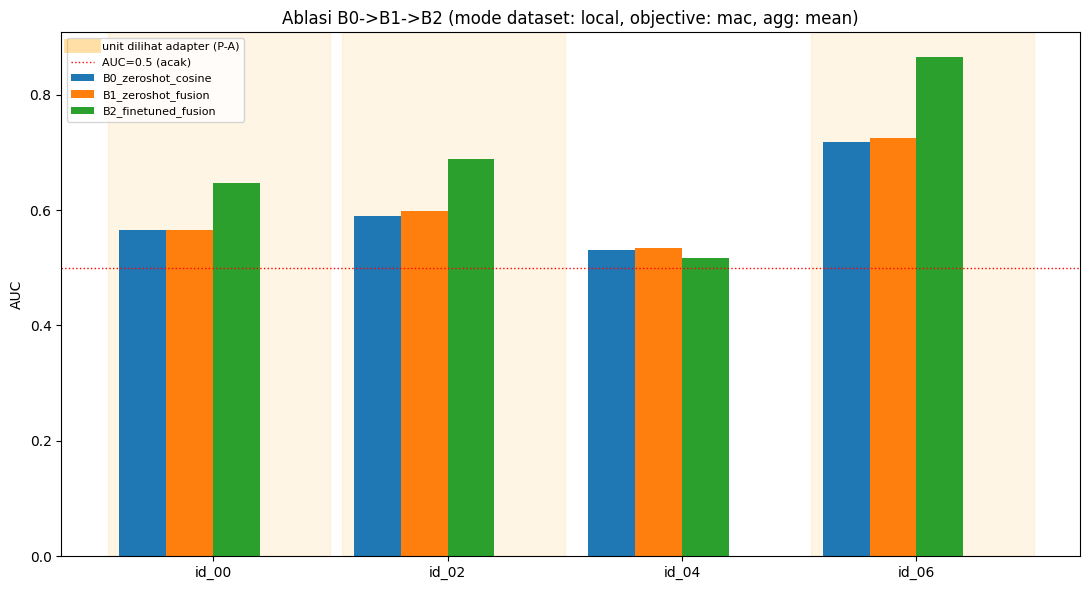

Plot tersimpan: ablation_results_local_mac_opt.png


In [42]:
fig, ax = plt.subplots(figsize=(11, 6))
stages_present = [s for s in ["B0_zeroshot_cosine", "B1_zeroshot_fusion", "B2_finetuned_fusion"] if s in pivot.columns]
x = np.arange(len(pivot.index))
width = 0.8 / (len(stages_present) + 1)

for i, stage in enumerate(stages_present):
    ax.bar(x + i * width, pivot[stage], width, label=stage)
if "baseline_resmi_hitachi" in pivot.columns:
    ax.bar(x + len(stages_present) * width, pivot["baseline_resmi_hitachi"], width,
           label="Baseline resmi Hitachi (DAE)", color="gray")

# Tandai unit yang pernah dilihat adapter -- angka B2-nya menjawab pertanyaan yang
# berbeda dari unit unseen, jadi tidak boleh dibaca sebagai satu deret yang setara.
for i, mid in enumerate(pivot.index):
    if bool(pivot.loc[mid, "unit_seen_by_adapter"]):
        ax.axvspan(i - 0.15, i + 0.8, color="orange", alpha=0.10, zorder=0)
ax.plot([], [], color="orange", alpha=0.35, linewidth=10, label="unit dilihat adapter (P-A)")

ax.set_xticks(x + width * len(stages_present) / 2)
ax.set_xticklabels(pivot.index)
ax.set_ylabel("AUC")
ax.set_title(f"Ablasi B0->B1->B2 (mode dataset: {DATASET_MODE}, objective: {TRAIN_OBJECTIVE}, agg: {PRIMARY_AGG})")
ax.axhline(0.5, color="red", linestyle=":", linewidth=1, label="AUC=0.5 (acak)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"ablation_results_{RUN_TAG}.png", dpi=150)
plt.show()
print(f"Plot tersimpan: ablation_results_{RUN_TAG}.png")


In [ ]:
lines = []
lines.append(f"# Hasil Ablasi B0 -> B1 -> B2 -- AUDIAX ({RUN_TAG})\n")
lines.append(
    f"dataset_mode={DATASET_MODE}, objective={TRAIN_OBJECTIVE}, "
    f"N_SEEDS={N_SEEDS_ABLATION}, MAX_TEST_CLIPS_PER_CLASS={MAX_TEST_CLIPS_PER_CLASS}, "
    f"agregasi utama={PRIMARY_AGG}\n"
)
lines.append(
    "\n## Cara membaca tabel ini\n\n"
    "Kolom `unit_seen_by_adapter` menentukan pertanyaan mana yang dijawab satu baris:\n\n"
    "- `True` (protokol **P-A**): adapter pernah dilatih pada klip LAIN dari unit ini.\n"
    "  Klip tesnya sendiri dicadangkan dan tidak pernah dilatihkan, jadi angkanya bukan\n"
    "  hafalan langsung -- tapi ini **bukan** kondisi deploy AUDIAX dan tidak boleh\n"
    "  dikutip sebagai klaim generalisasi.\n"
    "- `False` (protokol **P-B**): adapter tidak pernah melihat unit ini sama sekali.\n"
    "  Ini yang mencerminkan deploy sebenarnya (adapter dilatih di mesin lain; mesin\n"
    "  operator baru dan hanya dikalibrasi). **Hanya baris ini yang sah dikutip.**\n"
)
lines.append(
    "\n**Peringatan seed.** `N_SEEDS` hanya mengacak pemilihan klip kalibrasi/tes, "
    "BUKAN seed training. `auc_std` yang dilaporkan adalah variasi terhadap pilihan klip, "
    "bukan terhadap inisialisasi atau urutan training.\n"
)

lines.append("\n## AUC per unit per tahap\n\n")
lines.append(pivot.round(4).to_markdown())

stage_cols_md = [c for c in pivot.columns if c.startswith("B")]
lines.append("\n\n## Rata-rata per stage -- seluruh unit (campuran; B2 TIDAK dapat dikutip)\n\n")
lines.append(pivot[stage_cols_md].mean(numeric_only=True).round(4).to_markdown())

unseen_md = pivot[~pivot["unit_seen_by_adapter"].astype(bool)]
if len(unseen_md):
    lines.append("\n\n## Rata-rata per stage -- HANYA unit unseen (P-B, angka yang sah)\n\n")
    lines.append(unseen_md[stage_cols_md].mean(numeric_only=True).round(4).to_markdown())

lines.append("\n\n## Metrik operasional B2 pada ambang produksi\n\n")
lines.append(
    f"Ambang: z_warning={CFG.z_warning}, z_critical={CFG.z_critical}. "
    f"pAUC dihitung dengan max_fpr={CFG.pauc_max_fpr} (standar DCASE).\n\n"
)
lines.append(ops.round(4).to_markdown(index=False))

lines.append("\n\n## Pengaruh skema agregasi window -> klip\n\n")
lines.append(
    results_b2.groupby("agg_mode")[["auc_mean", "pauc_mean", "fpr_warn_mean", "recall_warn_mean"]]
    .mean().round(4).to_markdown()
)

lines.append(
    f"\n\n## Ablasi denoise HPSS\n\n"
    f"Unit {denoise_target_id}, agg={PRIMARY_AGG}, klip training adapter dikecualikan: "
    f"OFF={auc_denoise_off:.4f}, ON={auc_denoise_on:.4f}, "
    f"delta={auc_denoise_on - auc_denoise_off:+.4f}\n"
)

if len(dp_summary):
    lines.append("\n\n## Ablasi jalur data (zero-shot, tanpa retraining)\n\n")
    lines.append(dp_summary.round(4).to_markdown(index=False))
    lines.append(
        "\n\nAngka di atas ZERO-SHOT. Sebelum mengubah default apa pun di `ai/config.py`, "
        "setelan pemenang harus dikonfirmasi ulang setelah adapter dilatih dengan setelan itu.\n"
    )

with open(f"results_{RUN_TAG}.md", "w", encoding="utf-8") as f:
    f.write("".join(lines))

print(f"Tersimpan: results_{RUN_TAG}.md")


## 31. Ringkasan & Langkah Selanjutnya

### Yang sudah dikerjakan (T1–T4)

**T1 — protokol evaluasi yang jujur.** `evaluate_machine()` menerima `exclude_paths`;
B2 memanggilnya dengan `ADAPTER_TRAIN_PATHS` sehingga unit seen tidak lagi dinilai pada
klip yang persis dipakai melatihnya. Split Bagian 9 mencadangkan `per_unit_test_frac`
klip tes dari **setiap** unit seen. Hasil dipisah **P-A** (unit sendiri) dan **P-B**
(unit baru) — hanya P-B yang sah dikutip sebagai klaim generalisasi. Metrik tambahan:
**pAUC** (p=0.1, standar DCASE) dan perilaku pada ambang produksi (`fpr_warn`,
`recall_warn`, `fpr_crit`, `recall_crit`). Checkpoint dinamai
`beats_finetuned_{TRAIN_OBJECTIVE}.pt` supaya varian binary dan MAC tidak saling menimpa.

**T2 — Bagian 26b.** Matriks jarak cosine antar-centroid unit, dihitung dari embedding
zero-shot sehingga tidak bisa dipengaruhi pilihan split.

**T3 — Bagian 29b.** Delapan kombinasi `audio_channel` × `normalize_mode` ×
`enable_privacy_notch`, tiap kombinasi dievaluasi untuk tiga skema agregasi sekaligus.
Semua default **belum diubah** — mengikuti preseden Keputusan Desain #4.

**T4 — MAC + angular margin.** Objective adapter berpindah dari Focal Loss biner ke
**Machine Attribute Classification**: label yang dilatihkan adalah `machine_id`, dan
label normal/abnormal tidak pernah masuk ke training adapter (Keputusan Desain #1
terpenuhi). Empat perubahan yang menyertainya:

1. **`ArcFaceHead`** menggantikan `nn.Linear` + cross-entropy biasa. Cross-entropy
   linear mengoptimalkan separabilitas linear, sedangkan keempat backend scoring
   membaca geometri cosine/jarak — objective dan pemakaian tidak selaras. Skala dan
   margin tetap (bukan AdaCos) supaya tidak ada celah argumen soal auto-tuning.
   `CFG.mac_head="linear"` tersedia untuk mengablasi kontribusi angular margin.
2. **Training hanya dari klip normal.** Klip abnormal di `train_df`/`val_df` sengaja
   tidak dipakai sama sekali untuk training adapter.
3. **Early stopping pindah dari akurasi ke val loss**, dengan **silhouette** embedding
   validasi (metrik cosine, bebas label anomali) sebagai diagnostik. Dengan hanya 3
   kelas, akurasi jenuh dalam beberapa epoch dan patience habis sebelum backbone
   sempat belajar.
4. **Augmentasi disimetriskan** (`aug_n_per_clip` untuk semua klip) dan `aug_pitch()`
   memakai tile, bukan zero-pad. Kombinasi lama (4× abnormal vs 1× normal + zero-pad)
   membuat ekor senyap buatan hampir eksklusif milik kelas abnormal — artefak yang bisa
   dipelajari sebagai pengganti label.

### Yang belum dikerjakan

**T5 — adu adil.** Skor checkpoint binary lama vs MAC baru di harness T1 yang sama,
dilaporkan di P-A dan P-B. Perbandingan lama tidak sah karena versi binary dinilai pada
klip yang dilatihkan, sedangkan MAC tidak.

**Proxy task masih terbatas 3 kelas.** `machine_id` adalah satu-satunya atribut yang
tersedia di dataset ini, jadi ruang label MAC hanya sebesar jumlah unit seen. Ini
plafon nyata: setup MAC di DCASE memakai banyak atribut (tipe mesin, kecepatan, beban,
lokasi mikrofon). Kalau data lapangan nanti punya metadata seperti itu, memasukkannya
sebagai atribut tambahan akan memperkuat proxy task jauh lebih besar daripada
tuning hyperparameter ArcFace.

### Efisiensi yang masih tertunda

- `build_baseline()` O(n²): untuk tiap window kalibrasi ia menghitung ulang `np.cov` +
  `np.linalg.svd` 768-dim dari bank n−1. Sengaja tidak disentuh karena mencerminkan
  `ai/calibration.py`.
- Training belum memakai AMP (`torch.autocast`), `num_workers`, atau `pin_memory`.


---

## T6 — Optimasi Anti-Overfit (notebook `_optimized` ini)

Semua perubahan di bawah menyerang satu pertanyaan: **bagaimana mengalahkan BEATs beku
di unit yang belum pernah dilihat adapter, tanpa merusak fitur pretrained.**

| # | Perubahan | Letak | Cara mengablasi |
|---|---|---|---|
| 1 | Pooling mean+std (1536-dim) | Bagian 12 | `CFG.pooling="mean"` |
| 2 | LP-FT: head dulu, backbone belakangan | Bagian 15 | `CFG.use_lp_ft=False` |
| 3 | L2-SP menggantikan weight decay backbone | Bagian 14–15 | `CFG.l2sp_lambda=0` |
| 4 | EMA bobot | Bagian 15 | `CFG.use_ema=False` |
| 5 | Seleksi checkpoint via AUC anomali sintetis | Bagian 14b, 15 | `CFG.select_metric="val_loss"` |
| 6 | Pitch-shift dimatikan | Bagian 7 | `CFG.aug_use_pitch=True` |
| 7 | Weight interpolation (WiSE-FT) | Bagian 16b | `CFG.wise_alphas=(1.0,)` |

### Integritas angka — tiga hal yang tidak boleh dilanggar

1. **α dipilih dari AUC anomali sintetis pada unit *seen*, bukan dari AUC held-out.**
   Kolom `heldout_auc_report_only` di tabel Bagian 16b memang dicetak, tapi memakainya
   untuk memilih α berarti tuning di test set dan membatalkan seluruh klaim P-B.
2. **Anomali sintetis bukan pengganti evaluasi.** Ia hanya kriteria seleksi. Angka resmi
   tetap datang dari Bagian 26–28: kalibrasi per-unit, fusi 4 backend, protokol P-A/P-B.
3. **Hasil negatif tetap dilaporkan.** Kalau `alpha*=0`, artinya BEATs beku menang dan
   fine-tuning tidak memberi apa pun yang bertahan di unit baru. Itu temuan yang sah dan
   lebih kredibel daripada delta kecil yang diperoleh dengan memilih-milih.

### Yang masih terbuka

- **Seed training.** `N_SEEDS_ABLATION` hanya mengacak pemilihan klip, bukan inisialisasi
  atau urutan training. Untuk angka headline, jalankan ulang seluruh notebook dengan
  `CFG.seed` berbeda minimal 3 kali dan laporkan rerata ± simpangan baku.
- **`n_unfrozen_layers` belum diablasi.** Uji `{0, 1, 2}`. Nilai 0 berarti hanya
  `layer_norm` yang bergerak (mendekati BitFit) — dengan ruang label sekecil ini, itu
  kandidat kuat untuk menang.
- **Leave-one-unit-out.** Held-out tunggal `id_04` punya varians tinggi. Empat fold akan
  menghilangkan tuduhan cherry-picking.
- **Ruang label.** Tetap plafon terbesar: `machine_type x id` dari MIMII penuh menaikkan
  jumlah kelas jauh di atas jumlah unit seen, dan tidak ada loss yang bisa menggantikan
  itu.
